# 07. 모델 시각적 비교 — 실험 1 vs 실험 3

실험 1(patron_03, MinMaxScaler)과 실험 3(patron_07/08, Log Base) 두 모델의 검색 품질을 20개 쿼리로 비교한다. 정량 지표는 실험 3이 우수하지만, 시각적 유사도 평가 결과 **실험 1을 최종 채택**했다.

## 비교 결과 요약

| 지표 | 실험 1 (patron_03) | 실험 3 (patron_07/08) | 승자 |
|------|--------------------|-----------------------|------|
| 평균 중복 종목 수 | 2.20개 | 0.15개 | 실험 3 |
| Top-1 평균 L2 거리 | 0.1219 | 0.0463 | 실험 3 |
| Top-10 평균 L2 거리 | 0.1964 | 0.0614 | 실험 3 |
| **시각적 유사도** | **유사한 형태 검색** | **다른 형태 검색** | **실험 1** |

## 최종 결론

정량 지표만 보면 실험 3이 모든 항목에서 우수하다. 그러나 20개 쿼리의 실제 차트 이미지를 눈으로 확인한 결과, 실험 3의 검색 결과는 쿼리와 시각적으로 다른 형태의 패턴이 다수 포함됐다. 중복 종목이 적은 이유도 "다양한 유사 패턴"이 아니라 "다른 패턴까지 가깝다"는 L2 거리 압축 효과였다. 패턴 유사도 검색이 목적인 서비스에서는 **시각적 일치가 핵심**이므로 실험 1을 채택한다.

## 평가 방식

1. 두 모델의 Best 체크포인트를 로드 (patron_03 Val Loss 0.005174 / patron_07/08 Val Loss 0.138237)
2. 공통 172개 종목에서 시드 421로 20개 쿼리 선택
3. 전체 패턴 임베딩 생성 후 numpy L2 거리 벡터 연산으로 Top-10 추출
4. 통계 지표 집계 및 차트 이미지 시각적 비교

## 1. 라이브러리 임포트

PyTorch, numpy, pandas, matplotlib, seaborn을 불러오고 시각화 스타일을 설정한다. 두 모델의 검색 결과를 나란히 비교하기 위해 seaborn의 whitegrid 스타일을 사용한다.

In [1]:
import numpy as np
import pandas as pd
import os
import gc
import warnings
from tqdm import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Google Colab
from google.colab import drive

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("✅ 라이브러리 임포트 완료")
print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ CUDA: {torch.cuda.is_available()}")

✅ 라이브러리 임포트 완료
✅ PyTorch: 2.8.0+cu126
✅ CUDA: True


Google Drive를 마운트하고 patron_03(MinMaxScaler)과 patron_07/08(Log Base) 두 모델의 체크포인트 경로와 이미지 디렉터리를 각각 설정한다.

v1과 v2 이미지 아카이브를 모두 Colab 로컬로 복사·해제하고 메타데이터 CSV도 함께 준비한다. 비교 과정에서 두 버전 이미지에 빠르게 접근하기 위해 로컬 I/O를 사용한다.

## 2. 경로 설정 및 데이터 준비

GPU 사용 가능 여부를 확인하고 이름을 출력한다. 두 모델을 동시에 로드하기 전에 GPU 캐시를 비워 메모리를 확보한다.

v1과 v2가 동일한 아키텍처를 공유하므로 `ChartEmbeddingModel` 클래스를 한 번만 정의한다. 1채널 ResNet18 백본에 L2 정규화 512차원 출력을 적용한 구조로, 학습된 가중치만 다르다.

In [2]:
# Google Drive 마운트
drive.mount('/content/drive')

# 경로 설정
GDRIVE_BASE = '/content/drive/MyDrive/Patron'

# patron_03 경로
MODEL_V1_PATH = f'{GDRIVE_BASE}/models/best_model.pth'
DATA_V1_PATH = '/content/data'
IMAGE_V1_DIR = f'{DATA_V1_PATH}/images'

# patron_07/08 경로
MODEL_V2_PATH = f'{GDRIVE_BASE}/models_v2/best_model_v2.pth'
DATA_V2_PATH = '/content/data_v2'
IMAGE_V2_DIR = f'{DATA_V2_PATH}/images_v2'

print("="*60)
print("📁 경로 설정")
print("="*60)
print(f"[patron_03]")
print(f"  모델: {MODEL_V1_PATH}")
print(f"  이미지: {IMAGE_V1_DIR}")
print(f"\n[patron_07/08]")
print(f"  모델: {MODEL_V2_PATH}")
print(f"  이미지: {IMAGE_V2_DIR}")
print("="*60)

Mounted at /content/drive
📁 경로 설정
[patron_03]
  모델: /content/drive/MyDrive/Patron/models/best_model.pth
  이미지: /content/data/images

[patron_07/08]
  모델: /content/drive/MyDrive/Patron/models_v2/best_model_v2.pth
  이미지: /content/data_v2/images_v2


patron_03(Val Loss 0.005174)과 patron_07/08(Val Loss 0.138237) Best 체크포인트를 각각의 모델 인스턴스에 로드하고 eval 모드로 설정한다. Val Loss 차이가 크지만 이는 정규화 스케일 차이에 의한 것이며, 단순 비교는 의미 없다.

In [3]:
# patron_03 데이터 준비 (로컬 스토리지 사용)
print("📦 patron_03 데이터 복사 중...")
!mkdir -p {DATA_V1_PATH}
!cp {GDRIVE_BASE}/images.tar {DATA_V1_PATH}/

print("📂 patron_03 압축 해제 중...")
!tar -xf {DATA_V1_PATH}/images.tar -C {DATA_V1_PATH}/

# patron_03 메타데이터 복사
!cp {GDRIVE_BASE}/data/processed/metadata_all.csv {DATA_V1_PATH}/metadata_v1.csv

# patron_07/08 데이터 준비 (로컬 스토리지 사용)
print("\n📦 patron_07/08 데이터 복사 중...")
!mkdir -p {DATA_V2_PATH}
!cp {GDRIVE_BASE}/data_v2/images_v2.tar {DATA_V2_PATH}/

print("📂 patron_07/08 압축 해제 중...")
!tar -xf {DATA_V2_PATH}/images_v2.tar -C {DATA_V2_PATH}/

# patron_07/08 메타데이터 복사
!cp {GDRIVE_BASE}/data_v2/metadata_all.csv {DATA_V2_PATH}/metadata_v2.csv

print("\n✅ 데이터 준비 완료!")
!echo "patron_03 이미지 개수: $(ls {IMAGE_V1_DIR} | wc -l)"
!echo "patron_07/08 이미지 개수: $(ls {IMAGE_V2_DIR} | wc -l)"

📦 patron_03 데이터 복사 중...
📂 patron_03 압축 해제 중...

📦 patron_07/08 데이터 복사 중...
📂 patron_07/08 압축 해제 중...

✅ 데이터 준비 완료!
patron_03 이미지 개수: 49987
patron_07/08 이미지 개수: 50159


두 버전 메타데이터를 불러오고 공통 종목 교집합을 계산한다. 172개 종목이 양쪽에 모두 존재해 공정한 비교가 가능함을 확인한다(patron_03: 49,987패턴 / patron_07/08: 50,159패턴).

공통 172개 종목에서 시드 421로 20개 쿼리를 무작위 선택한다. 두 모델이 동일한 입력 이미지를 받도록 v1과 v2에서 같은 `pattern_id`를 매칭해 비교 공정성을 보장한다.

## 3. GPU 확인 및 모델 정의

모든 패턴을 각 모델에 통과시켜 v1(49,987×512)과 v2(50,159×512) 두 임베딩 행렬을 생성한다. `no_grad` 모드로 실행해 메모리를 절약하고, 각각 약 3분이 소요된다.

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 디바이스: {device}")

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    torch.cuda.empty_cache()
    gc.collect()

🔥 디바이스: cuda
✅ GPU: NVIDIA A100-SXM4-40GB


20개 쿼리 각각에 대해 numpy 벡터 연산으로 L2 거리를 계산하고 자기 자신을 제외한 Top-10을 추출한다. 같은 종목 중복 수와 거리를 두 모델 모두 기록한다.

In [5]:
class ChartEmbeddingModel(nn.Module):
    def __init__(self, embedding_dim=512):
        super(ChartEmbeddingModel, self).__init__()
        resnet = models.resnet18(pretrained=False)
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.embedding_dim = embedding_dim

    def forward(self, x):
        features = self.features(x)
        embeddings = features.view(features.size(0), -1)
        embeddings = F.normalize(embeddings, p=2, dim=1)
        return embeddings

print("✅ 모델 클래스 정의 완료")

✅ 모델 클래스 정의 완료


20개 쿼리의 중복 개수, Top-1 거리, Top-10 평균 거리를 집계해 출력한다. 세 지표 모두 patron_07/08이 수치적으로 우수하지만, 이 결과만으로 최종 모델을 선택하지 않는다. 다음 섹션의 시각적 비교가 핵심이다.

## 4. 모델 로드

20개 쿼리의 중복 종목 수를 히스토그램과 박스플롯으로 나란히 시각화한다. patron_03 평균 2.20개 vs patron_07/08 평균 0.15개의 차이를 한눈에 확인한다. 수치만 보면 patron_07/08이 압도적으로 우세하다.

In [6]:
# patron_03 모델 로드
print("📥 patron_03 모델 로드 중...")
model_v1 = ChartEmbeddingModel(embedding_dim=512).to(device)
checkpoint_v1 = torch.load(MODEL_V1_PATH, map_location=device)
model_v1.load_state_dict(checkpoint_v1['model_state_dict'])
model_v1.eval()
print(f"✅ patron_03 로드 완료 (Epoch {checkpoint_v1['epoch']}, Val Loss: {checkpoint_v1['val_loss']:.6f})")

# patron_07/08 모델 로드
print("\n📥 patron_07/08 모델 로드 중...")
model_v2 = ChartEmbeddingModel(embedding_dim=512).to(device)
checkpoint_v2 = torch.load(MODEL_V2_PATH, map_location=device)
model_v2.load_state_dict(checkpoint_v2['model_state_dict'])
model_v2.eval()
print(f"✅ patron_07/08 로드 완료 (Epoch {checkpoint_v2['epoch']}, Val Loss: {checkpoint_v2['val_loss']:.6f})")

print("\n" + "="*60)
print("🎉 두 모델 로드 완료!")
print("="*60)

📥 patron_03 모델 로드 중...
✅ patron_03 로드 완료 (Epoch 1, Val Loss: 0.005174)

📥 patron_07/08 모델 로드 중...
✅ patron_07/08 로드 완료 (Epoch 2, Val Loss: 0.138237)

🎉 두 모델 로드 완료!


## 5. 쿼리 선택 (20개)

두 버전 메타데이터를 합쳐 172개 공통 종목을 확인하고, 시드 421로 20개 쿼리를 무작위 선택한다. v1과 v2에서 동일한 `pattern_id`를 매칭해 비교의 공정성을 보장한다.

In [7]:
# 메타데이터 로드
metadata_v1 = pd.read_csv(f'{DATA_V1_PATH}/metadata_v1.csv')
metadata_v2 = pd.read_csv(f'{DATA_V2_PATH}/metadata_v2.csv')

print("📊 메타데이터 로드 완료")
print(f"patron_03: {len(metadata_v1):,}개 패턴")
print(f"patron_07/08: {len(metadata_v2):,}개 패턴")
print(f"\n✅ patron_03 컬럼: {list(metadata_v1.columns)}")
print(f"✅ patron_07/08 컬럼: {list(metadata_v2.columns)}")

# 공통 종목 찾기
common_tickers = set(metadata_v1['ticker'].unique()) & set(metadata_v2['ticker'].unique())
common_tickers = sorted(list(common_tickers))
print(f"\n✅ 공통 종목: {len(common_tickers)}개")
print(f"예시: {common_tickers[:10]}")

📊 메타데이터 로드 완료
patron_03: 49,987개 패턴
patron_07/08: 50,159개 패턴

✅ patron_03 컬럼: ['ticker', 'pattern_id', 'start_date', 'end_date', 'start_price', 'end_price', 'sector', 'industry', 'return_3m', 'return_6m', 'return_1y']
✅ patron_07/08 컬럼: ['ticker', 'pattern_id', 'start_date', 'end_date', 'start_price', 'end_price', 'sector', 'industry', 'return_3m', 'return_6m', 'return_1y']

✅ 공통 종목: 172개
예시: ['AAPL', 'ABBV', 'ABNB', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADP', 'ADSK', 'AEP']


In [19]:
# 랜덤 쿼리 20개 선택
np.random.seed(421)

query_list = []

# 공통 종목에서 랜덤 선택
selected_tickers = np.random.choice(common_tickers, size=20, replace=False)

for ticker in selected_tickers:
    # 각 종목에서 랜덤 패턴 하나 선택
    ticker_patterns_v1 = metadata_v1[metadata_v1['ticker'] == ticker]
    ticker_patterns_v2 = metadata_v2[metadata_v2['ticker'] == ticker]

    # 공통 pattern_id 찾기 (같은 시기)
    common_patterns = set(ticker_patterns_v1['pattern_id']) & set(ticker_patterns_v2['pattern_id'])

    if len(common_patterns) > 0:
        pattern_id = np.random.choice(list(common_patterns))

        # v1, v2에서 해당 패턴 찾기
        idx_v1 = ticker_patterns_v1[ticker_patterns_v1['pattern_id'] == pattern_id].index[0]
        idx_v2 = ticker_patterns_v2[ticker_patterns_v2['pattern_id'] == pattern_id].index[0]

        query_list.append({
            'ticker': ticker,
            'pattern_id': pattern_id,
            'idx_v1': idx_v1,
            'idx_v2': idx_v2
        })

print(f"\n✅ 쿼리 20개 선택 완료")
print("\n" + "="*60)
print("쿼리 목록:")
print("="*60)
for i, q in enumerate(query_list, 1):
    print(f"{i:2d}. {q['ticker']:6s} | Pattern {q['pattern_id']:3d}")
print("="*60)


✅ 쿼리 20개 선택 완료

쿼리 목록:
 1. GM     | Pattern 169
 2. WBD    | Pattern 242
 3. ODFL   | Pattern 248
 4. AAPL   | Pattern 293
 5. ADSK   | Pattern  23
 6. PAYX   | Pattern 134
 7. PG     | Pattern  82
 8. MRK    | Pattern 203
 9. TRI    | Pattern 290
10. ^IXIC  | Pattern  72
11. LIN    | Pattern 251
12. MDT    | Pattern 187
13. UNP    | Pattern 203
14. MMM    | Pattern 164
15. CRM    | Pattern 213
16. WMT    | Pattern 144
17. VZ     | Pattern  58
18. ZS     | Pattern 176
19. UPS    | Pattern  43
20. TTWO   | Pattern 163


## 6. 전체 임베딩 생성

두 모델의 전체 패턴 임베딩을 생성한다. patron_03은 49,987개, patron_07/08은 50,159개를 각각 처리해 (N×512) 크기의 float32 행렬을 만든다. 이후 벡터 연산 기반 검색에 사용된다.

In [20]:
print("🚀 전체 임베딩 생성 시작!")
print("="*60)

# patron_03 전체 임베딩 생성
print("\n📦 patron_03 임베딩 생성 중...")
embeddings_v1_list = []

with torch.no_grad():
    for idx in tqdm(metadata_v1.index, desc="patron_03", leave=True):
        ticker = metadata_v1.loc[idx, 'ticker']
        pattern_id = metadata_v1.loc[idx, 'pattern_id']
        img_path = f"{IMAGE_V1_DIR}/{ticker}_{pattern_id}.npy"

        try:
            img = np.load(img_path)
            img_tensor = torch.FloatTensor(img).unsqueeze(0).unsqueeze(0).to(device) / 255.0
            embedding = model_v1(img_tensor).squeeze(0).cpu().numpy()
            embeddings_v1_list.append(embedding)
        except:
            embeddings_v1_list.append(np.zeros(512, dtype=np.float32))

embeddings_v1 = np.vstack(embeddings_v1_list).astype('float32')
print(f"✅ patron_03 임베딩 완료: {embeddings_v1.shape}")

# patron_07/08 전체 임베딩 생성
print("\n📦 patron_07/08 임베딩 생성 중...")
embeddings_v2_list = []

with torch.no_grad():
    for idx in tqdm(metadata_v2.index, desc="patron_07/08", leave=True):
        ticker = metadata_v2.loc[idx, 'ticker']
        pattern_id = metadata_v2.loc[idx, 'pattern_id']
        img_path = f"{IMAGE_V2_DIR}/{ticker}_{pattern_id}.npy"

        try:
            img = np.load(img_path)
            img_tensor = torch.FloatTensor(img).unsqueeze(0).unsqueeze(0).to(device) / 255.0
            embedding = model_v2(img_tensor).squeeze(0).cpu().numpy()
            embeddings_v2_list.append(embedding)
        except:
            embeddings_v2_list.append(np.zeros(512, dtype=np.float32))

embeddings_v2 = np.vstack(embeddings_v2_list).astype('float32')
print(f"✅ patron_07/08 임베딩 완료: {embeddings_v2.shape}")

# 메모리 정리
torch.cuda.empty_cache()
gc.collect()

print("\n" + "="*60)
print("🎉 전체 임베딩 생성 완료!")
print(f"📊 patron_03: {embeddings_v1.shape}")
print(f"📊 patron_07/08: {embeddings_v2.shape}")
print("="*60)

🚀 전체 임베딩 생성 시작!

📦 patron_03 임베딩 생성 중...


patron_03: 100%|██████████| 49987/49987 [02:46<00:00, 300.82it/s]


✅ patron_03 임베딩 완료: (49987, 512)

📦 patron_07/08 임베딩 생성 중...


patron_07/08: 100%|██████████| 50159/50159 [02:45<00:00, 303.82it/s]


✅ patron_07/08 임베딩 완료: (50159, 512)

🎉 전체 임베딩 생성 완료!
📊 patron_03: (49987, 512)
📊 patron_07/08: (50159, 512)


## 7. 벡터 연산 기반 검색

numpy 벡터 연산으로 20개 쿼리 각각의 L2 거리를 전체 데이터베이스와 계산해 Top-10을 추출한다. 자기 자신을 제외하고 같은 종목 중복 수와 거리를 두 모델 모두 기록한다.

In [21]:
# 결과 저장
results = []

print("="*80)
print("🔍 20개 쿼리 검색 시작! (벡터 연산)")
print("="*80)

for i, query in enumerate(query_list, 1):
    print(f"\n[{i}/20] 쿼리: {query['ticker']}_{query['pattern_id']}")
    print("-" * 60)

    # patron_03 검색 (벡터 연산)
    query_emb_v1 = embeddings_v1[query['idx_v1']]
    distances_v1 = np.sum((embeddings_v1 - query_emb_v1) ** 2, axis=1)  # L2 Distance

    # 자기 자신 제외하고 Top-10
    sorted_indices_v1 = np.argsort(distances_v1)
    top10_v1 = [idx for idx in sorted_indices_v1 if idx != query['idx_v1']][:10]
    dist_v1 = [distances_v1[idx] for idx in top10_v1]

    # patron_07/08 검색 (벡터 연산)
    query_emb_v2 = embeddings_v2[query['idx_v2']]
    distances_v2 = np.sum((embeddings_v2 - query_emb_v2) ** 2, axis=1)  # L2 Distance

    # 자기 자신 제외하고 Top-10
    sorted_indices_v2 = np.argsort(distances_v2)
    top10_v2 = [idx for idx in sorted_indices_v2 if idx != query['idx_v2']][:10]
    dist_v2 = [distances_v2[idx] for idx in top10_v2]

    # 중복 개수 계산
    duplicates_v1 = sum(1 for idx in top10_v1 if metadata_v1.loc[idx, 'ticker'] == query['ticker'])
    duplicates_v2 = sum(1 for idx in top10_v2 if metadata_v2.loc[idx, 'ticker'] == query['ticker'])

    # 결과 저장
    results.append({
        'query_id': i,
        'ticker': query['ticker'],
        'pattern_id': query['pattern_id'],
        'top10_v1': top10_v1,
        'dist_v1': dist_v1,
        'duplicates_v1': duplicates_v1,
        'top10_v2': top10_v2,
        'dist_v2': dist_v2,
        'duplicates_v2': duplicates_v2,
    })

    print(f"  ✅ patron_03: 중복 {duplicates_v1}개, 평균거리 {np.mean(dist_v1):.4f}")
    print(f"  ✅ patron_07/08: 중복 {duplicates_v2}개, 평균거리 {np.mean(dist_v2):.4f}")

print("\n" + "="*80)
print("🎉 전체 검색 완료!")
print("="*80)

🔍 20개 쿼리 검색 시작! (벡터 연산)

[1/20] 쿼리: GM_169
------------------------------------------------------------
  ✅ patron_03: 중복 2개, 평균거리 0.1773
  ✅ patron_07/08: 중복 0개, 평균거리 0.0783

[2/20] 쿼리: WBD_242
------------------------------------------------------------
  ✅ patron_03: 중복 1개, 평균거리 0.2232
  ✅ patron_07/08: 중복 0개, 평균거리 0.0856

[3/20] 쿼리: ODFL_248
------------------------------------------------------------
  ✅ patron_03: 중복 3개, 평균거리 0.1920
  ✅ patron_07/08: 중복 0개, 평균거리 0.0586

[4/20] 쿼리: AAPL_293
------------------------------------------------------------
  ✅ patron_03: 중복 1개, 평균거리 0.1629
  ✅ patron_07/08: 중복 0개, 평균거리 0.0195

[5/20] 쿼리: ADSK_23
------------------------------------------------------------
  ✅ patron_03: 중복 2개, 평균거리 0.1991
  ✅ patron_07/08: 중복 0개, 평균거리 0.0406

[6/20] 쿼리: PAYX_134
------------------------------------------------------------
  ✅ patron_03: 중복 2개, 평균거리 0.0987
  ✅ patron_07/08: 중복 0개, 평균거리 0.0564

[7/20] 쿼리: PG_82
--------------------------------------------

## 8. 정량 통계 요약

중복 개수와 Top-1/Top-10 거리의 평균·최솟값·최댓값·표준편차를 계산해 출력한다. patron_07/08이 세 지표 모두에서 수치적으로 우수하지만, 이는 시각적 평가의 전제가 아니라 참고 지표다.

In [11]:
# 통계 계산
duplicates_v1 = [r['duplicates_v1'] for r in results]
duplicates_v2 = [r['duplicates_v2'] for r in results]

avg_dist_v1 = [np.mean(r['dist_v1']) for r in results]
avg_dist_v2 = [np.mean(r['dist_v2']) for r in results]

min_dist_v1 = [r['dist_v1'][0] for r in results]  # Top-1 거리
min_dist_v2 = [r['dist_v2'][0] for r in results]

print("="*80)
print("📊 통계 요약")
print("="*80)
print("\n[중복 개수]")
print(f"patron_03    : 평균 {np.mean(duplicates_v1):.2f}개 | 최소 {np.min(duplicates_v1)}개 | 최대 {np.max(duplicates_v1)}개 | 표준편차 {np.std(duplicates_v1):.2f}")
print(f"patron_07/08 : 평균 {np.mean(duplicates_v2):.2f}개 | 최소 {np.min(duplicates_v2)}개 | 최대 {np.max(duplicates_v2)}개 | 표준편차 {np.std(duplicates_v2):.2f}")

print("\n[Top-1 거리 (가장 유사)]")
print(f"patron_03    : 평균 {np.mean(min_dist_v1):.4f} | 표준편차 {np.std(min_dist_v1):.4f}")
print(f"patron_07/08 : 평균 {np.mean(min_dist_v2):.4f} | 표준편차 {np.std(min_dist_v2):.4f}")

print("\n[Top-10 평균 거리]")
print(f"patron_03    : 평균 {np.mean(avg_dist_v1):.4f} | 표준편차 {np.std(avg_dist_v1):.4f}")
print(f"patron_07/08 : 평균 {np.mean(avg_dist_v2):.4f} | 표준편차 {np.std(avg_dist_v2):.4f}")

print("\n[승자 판정]")
print(f"중복 적음:   {'patron_07/08 ✅' if np.mean(duplicates_v2) < np.mean(duplicates_v1) else 'patron_03'}")
print(f"Top-1 가까움: {'patron_07/08 ✅' if np.mean(min_dist_v2) < np.mean(min_dist_v1) else 'patron_03'}")
print(f"평균 가까움: {'patron_07/08 ✅' if np.mean(avg_dist_v2) < np.mean(avg_dist_v1) else 'patron_03'}")
print("="*80)

📊 통계 요약

[중복 개수]
patron_03    : 평균 2.20개 | 최소 1개 | 최대 4개 | 표준편차 1.03
patron_07/08 : 평균 0.15개 | 최소 0개 | 최대 1개 | 표준편차 0.36

[Top-1 거리 (가장 유사)]
patron_03    : 평균 0.1219 | 표준편차 0.0501
patron_07/08 : 평균 0.0463 | 표준편차 0.0177

[Top-10 평균 거리]
patron_03    : 평균 0.1964 | 표준편차 0.0484
patron_07/08 : 평균 0.0614 | 표준편차 0.0141

[승자 판정]
중복 적음:   patron_07/08 ✅
Top-1 가까움: patron_07/08 ✅
평균 가까움: patron_07/08 ✅


## 9. 시각화 1 — 중복 종목 수 분포

20개 쿼리에서 같은 종목이 Top-10에 몇 번 등장했는지를 히스토그램과 박스플롯으로 비교한다. patron_03 평균 2.20개 vs patron_07/08 평균 0.15개. 단, 중복이 많다고 무조건 나쁜 것은 아니다 — 진짜 유사 패턴이 같은 종목에서 나올 수 있다.

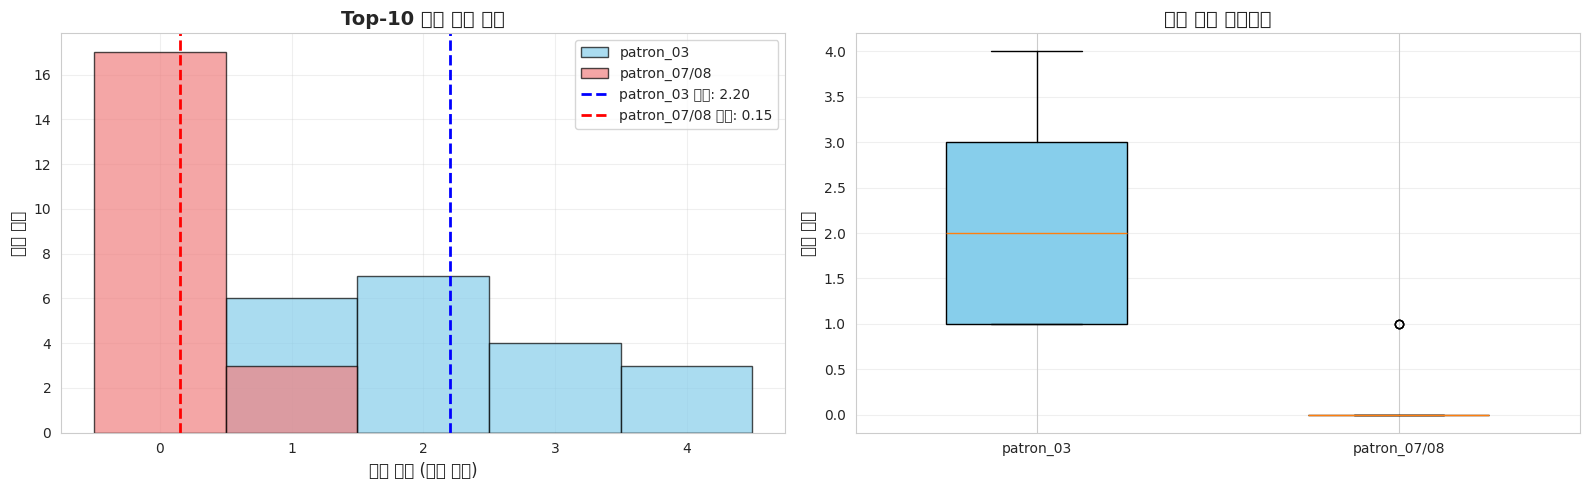

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
bins = np.arange(-0.5, max(max(duplicates_v1), max(duplicates_v2)) + 1.5, 1)

axes[0].hist(duplicates_v1, bins=bins, alpha=0.7, label='patron_03', color='skyblue', edgecolor='black')
axes[0].hist(duplicates_v2, bins=bins, alpha=0.7, label='patron_07/08', color='lightcoral', edgecolor='black')
axes[0].axvline(np.mean(duplicates_v1), color='blue', linestyle='--', linewidth=2, label=f'patron_03 평균: {np.mean(duplicates_v1):.2f}')
axes[0].axvline(np.mean(duplicates_v2), color='red', linestyle='--', linewidth=2, label=f'patron_07/08 평균: {np.mean(duplicates_v2):.2f}')
axes[0].set_xlabel('중복 개수 (같은 종목)', fontsize=12)
axes[0].set_ylabel('쿼리 개수', fontsize=12)
axes[0].set_title('Top-10 중복 개수 분포', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Box Plot
data = [duplicates_v1, duplicates_v2]
bp = axes[1].boxplot(data, labels=['patron_03', 'patron_07/08'], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('skyblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('중복 개수', fontsize=12)
axes[1].set_title('중복 개수 박스플롯', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 10. 시각화 2 — L2 거리 분포

Top-1 거리와 Top-10 평균 거리를 박스플롯으로 나란히 시각화한다. patron_07/08이 더 낮은 거리값을 가진다. 그러나 거리가 낮다고 시각적으로 유사한 것은 아니다 — Log 정규화 공간에서 거리가 압축됐을 뿐일 수 있다.

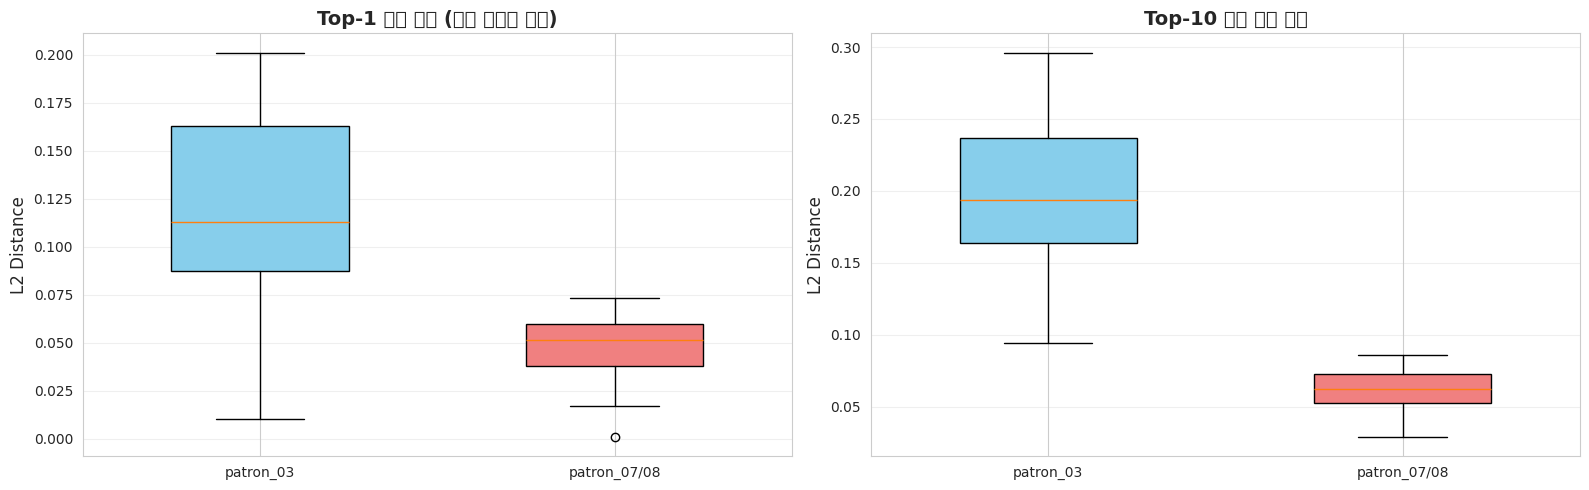

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top-1 거리 박스플롯
data = [min_dist_v1, min_dist_v2]
bp = axes[0].boxplot(data, labels=['patron_03', 'patron_07/08'], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('skyblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0].set_ylabel('L2 Distance', fontsize=12)
axes[0].set_title('Top-1 거리 분포 (가장 유사한 패턴)', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# Top-10 평균 거리 박스플롯
data = [avg_dist_v1, avg_dist_v2]
bp = axes[1].boxplot(data, labels=['patron_03', 'patron_07/08'], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('skyblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('L2 Distance', fontsize=12)
axes[1].set_title('Top-10 평균 거리 분포', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 11. 시각화 3 — 중복 수 vs 평균 거리 산점도

중복 개수와 Top-10 평균 거리의 관계를 산점도로 그린다. 왼쪽 아래(중복 적고 거리 가까움)가 이상적이며, patron_07/08이 해당 영역에 집중된다. 그러나 시각적 비교에서 이 영역의 patron_07/08 결과가 실제로 시각적으로 유사한지는 별도로 확인해야 한다.

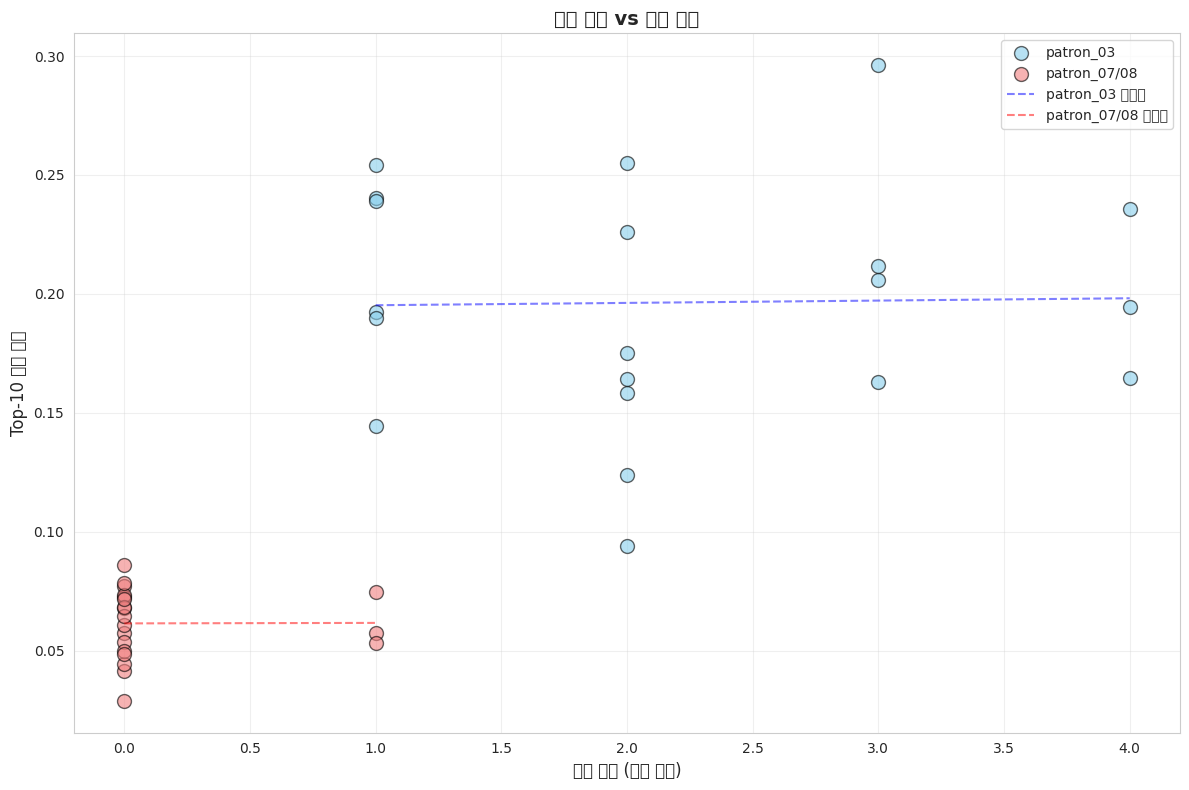


해석:
- 왼쪽 아래 = 중복 적고 거리 가까움 (이상적!)
- 오른쪽 위 = 중복 많고 거리 멂 (나쁨!)


In [14]:
fig, ax = plt.subplots(figsize=(12, 8))

# patron_03
ax.scatter(duplicates_v1, avg_dist_v1, s=100, alpha=0.6, label='patron_03', color='skyblue', edgecolor='black')

# patron_07/08
ax.scatter(duplicates_v2, avg_dist_v2, s=100, alpha=0.6, label='patron_07/08', color='lightcoral', edgecolor='black')

ax.set_xlabel('중복 개수 (같은 종목)', fontsize=12)
ax.set_ylabel('Top-10 평균 거리', fontsize=12)
ax.set_title('중복 개수 vs 평균 거리', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

# 추세선
z1 = np.polyfit(duplicates_v1, avg_dist_v1, 1)
p1 = np.poly1d(z1)
ax.plot(sorted(duplicates_v1), p1(sorted(duplicates_v1)), "--", color='blue', alpha=0.5, label='patron_03 추세선')

z2 = np.polyfit(duplicates_v2, avg_dist_v2, 1)
p2 = np.poly1d(z2)
ax.plot(sorted(duplicates_v2), p2(sorted(duplicates_v2)), "--", color='red', alpha=0.5, label='patron_07/08 추세선')

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\n해석:")
print("- 왼쪽 아래 = 중복 적고 거리 가까움 (이상적!)")
print("- 오른쪽 위 = 중복 많고 거리 멂 (나쁨!)")

## 12. 시각화 4 — 쿼리별 바 차트 비교

20개 쿼리별 중복 개수와 평균 거리를 바 차트로 비교한다. 쿼리마다 두 모델의 성능 차이를 직관적으로 확인할 수 있으며, 일부 쿼리(MRK, WMT 등)에서 patron_07/08도 일정 수준의 중복이 발생함을 볼 수 있다.

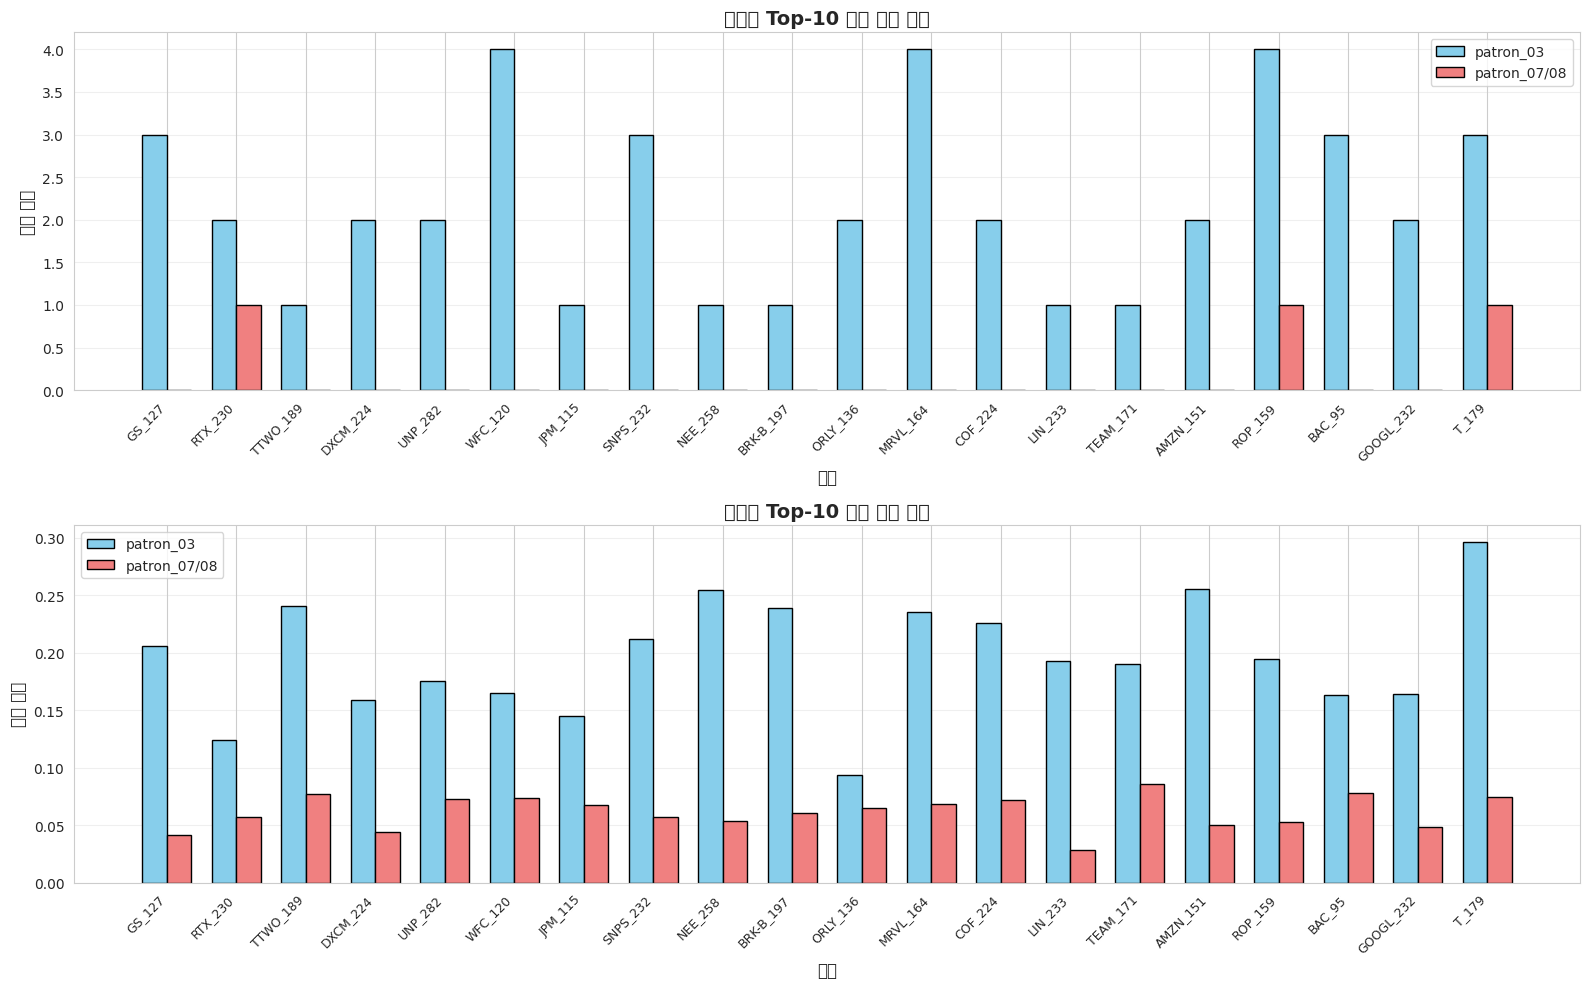

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

query_labels = [f"{r['ticker']}_{r['pattern_id']}" for r in results]
x = np.arange(len(query_labels))
width = 0.35

# 중복 개수
axes[0].bar(x - width/2, duplicates_v1, width, label='patron_03', color='skyblue', edgecolor='black')
axes[0].bar(x + width/2, duplicates_v2, width, label='patron_07/08', color='lightcoral', edgecolor='black')
axes[0].set_xlabel('쿼리', fontsize=12)
axes[0].set_ylabel('중복 개수', fontsize=12)
axes[0].set_title('쿼리별 Top-10 중복 개수 비교', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(query_labels, rotation=45, ha='right', fontsize=9)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, axis='y')

# 평균 거리
axes[1].bar(x - width/2, avg_dist_v1, width, label='patron_03', color='skyblue', edgecolor='black')
axes[1].bar(x + width/2, avg_dist_v2, width, label='patron_07/08', color='lightcoral', edgecolor='black')
axes[1].set_xlabel('쿼리', fontsize=12)
axes[1].set_ylabel('평균 거리', fontsize=12)
axes[1].set_title('쿼리별 Top-10 평균 거리 비교', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(query_labels, rotation=45, ha='right', fontsize=9)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 13. 시각화 5 — 차트 이미지 시각적 비교 (20개 전부)

20개 쿼리 각각에 대해 두 모델의 Top-10 검색 결과를 차트 이미지로 나란히 보여주는 시각화 함수를 정의하고 실행한다. 이 시각적 비교가 최종 모델 선택의 핵심 근거다 — 정량 지표만으로는 놓치는 시각적 유사도를 눈으로 직접 확인한다.

In [ ]:
def display_query_comparison(result, metadata_v1, metadata_v2, image_v1_dir, image_v2_dir):
    """
    쿼리 하나에 대한 시각적 비교
    
    Row 1: 쿼리
    Row 2: patron_03 Top-10
    Row 3: patron_07/08 Top-10
    """
    fig = plt.figure(figsize=(24, 8))
    gs = GridSpec(3, 11, figure=fig, hspace=0.4, wspace=0.3)
    
    query_ticker = result['ticker']
    query_pattern = result['pattern_id']
    
    # 쿼리 이미지
    ax_query = fig.add_subplot(gs[0, :2])
    query_img_path = f"{image_v1_dir}/{query_ticker}_{query_pattern}.npy"
    query_img = np.load(query_img_path)
    ax_query.imshow(query_img, cmap='gray', aspect='auto')
    ax_query.set_title(f'QUERY\n{query_ticker}_{query_pattern}', fontsize=12, fontweight='bold')
    ax_query.axis('off')
    
    # patron_03 Top-10
    for i, (idx, dist) in enumerate(zip(result['top10_v1'], result['dist_v1'])):
        ax = fig.add_subplot(gs[1, i])
        ticker = metadata_v1.loc[idx, 'ticker']
        pattern_id = metadata_v1.loc[idx, 'pattern_id']
        img_path = f"{image_v1_dir}/{ticker}_{pattern_id}.npy"
        img = np.load(img_path)
        ax.imshow(img, cmap='gray', aspect='auto')
        
        same_ticker = '⭐' if ticker == query_ticker else ''
        ax.set_title(f'{ticker}\n{same_ticker}\n{dist:.4f}', fontsize=9)
        ax.axis('off')
    
    # Label
    ax_label_v1 = fig.add_subplot(gs[1, 10])
    ax_label_v1.text(0.5, 0.5, f'patron_03\n중복: {result["duplicates_v1"]}개\n평균: {np.mean(result["dist_v1"]):.4f}', 
                     ha='center', va='center', fontsize=11, fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='skyblue', alpha=0.3))
    ax_label_v1.axis('off')
    
    # patron_07/08 Top-10
    for i, (idx, dist) in enumerate(zip(result['top10_v2'], result['dist_v2'])):
        ax = fig.add_subplot(gs[2, i])
        ticker = metadata_v2.loc[idx, 'ticker']
        pattern_id = metadata_v2.loc[idx, 'pattern_id']
        img_path = f"{image_v2_dir}/{ticker}_{pattern_id}.npy"
        img = np.load(img_path)
        ax.imshow(img, cmap='gray', aspect='auto')
        
        same_ticker = '⭐' if ticker == query_ticker else ''
        ax.set_title(f'{ticker}\n{same_ticker}\n{dist:.4f}', fontsize=9)
        ax.axis('off')
    
    # Label
    ax_label_v2 = fig.add_subplot(gs[2, 10])
    ax_label_v2.text(0.5, 0.5, f'patron_07/08\n중복: {result["duplicates_v2"]}개\n평균: {np.mean(result["dist_v2"]):.4f}', 
                     ha='center', va='center', fontsize=11, fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))
    ax_label_v2.axis('off')
    
    plt.suptitle(f'Query #{result["query_id"]}: {query_ticker}_{query_pattern}', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.show()

print("✅ 시각화 함수 정의 완료")

🖼️ 쿼리별 차트 이미지 비교 (20개)


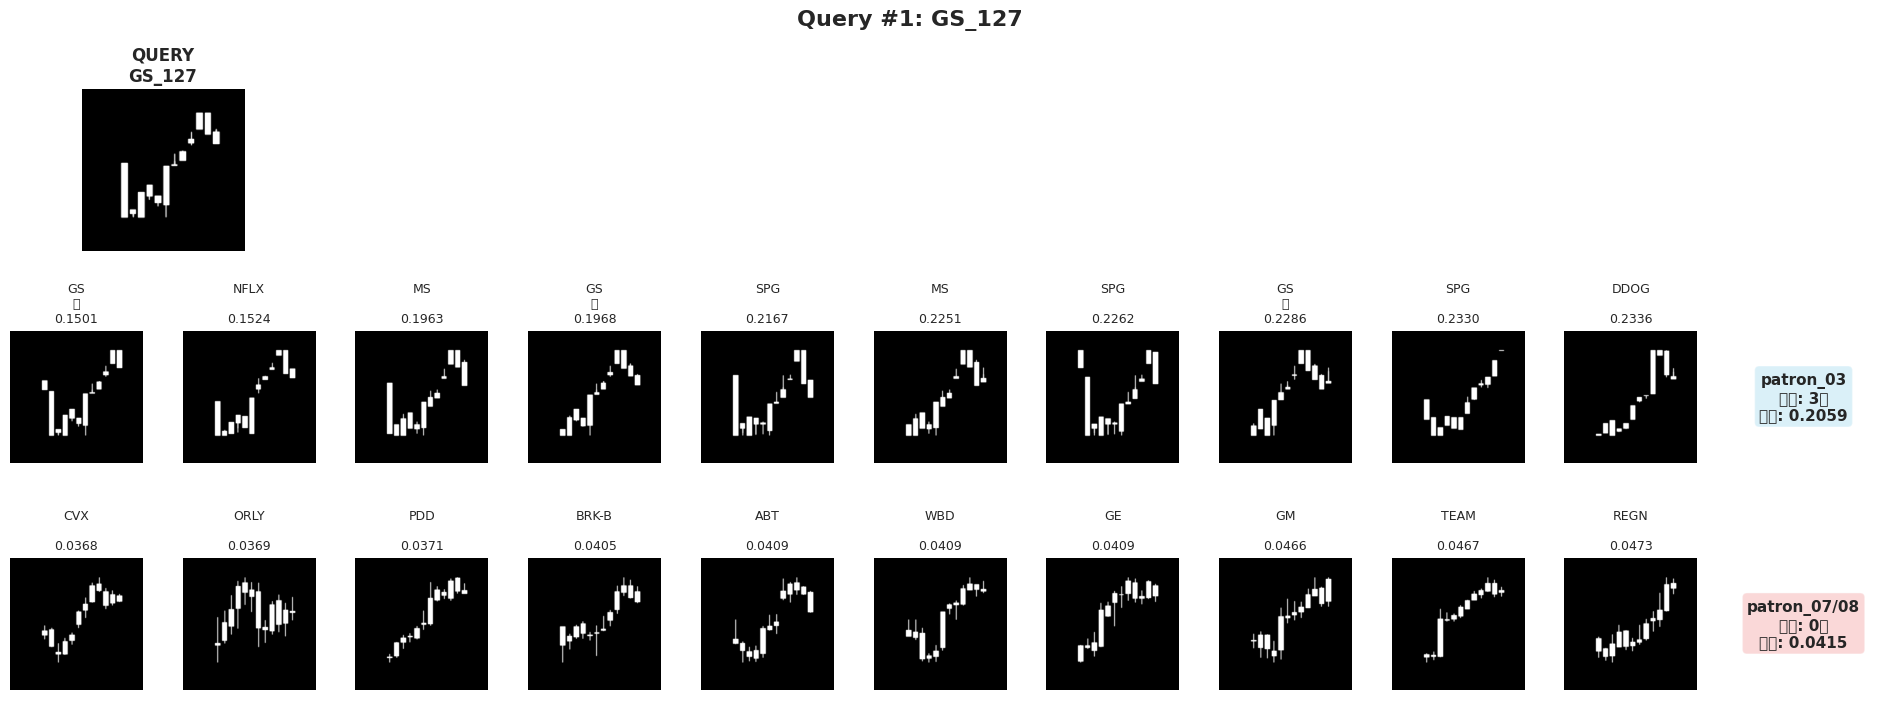

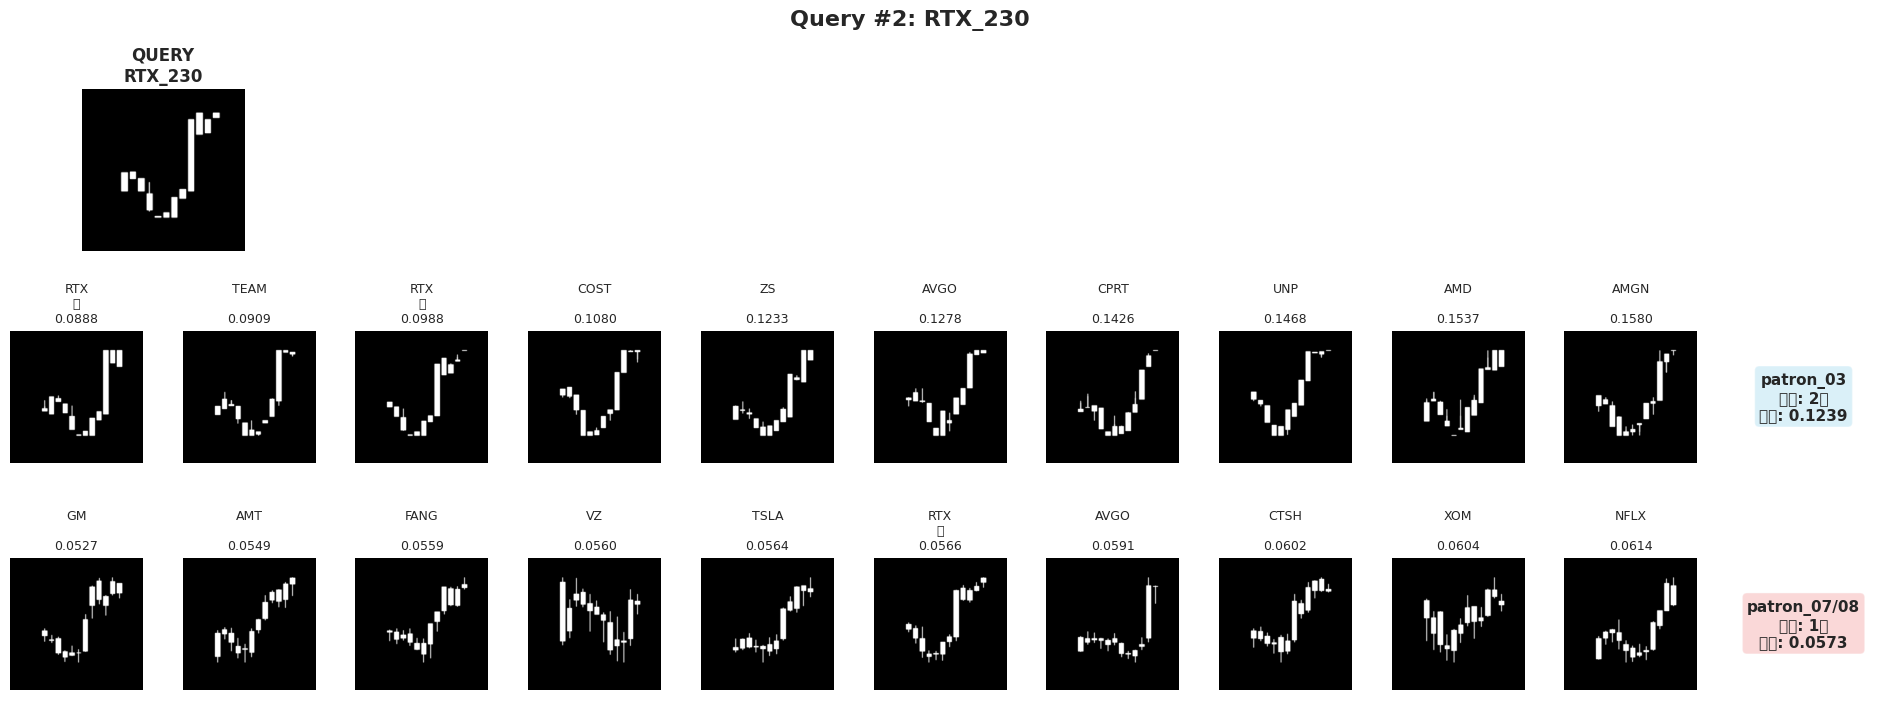

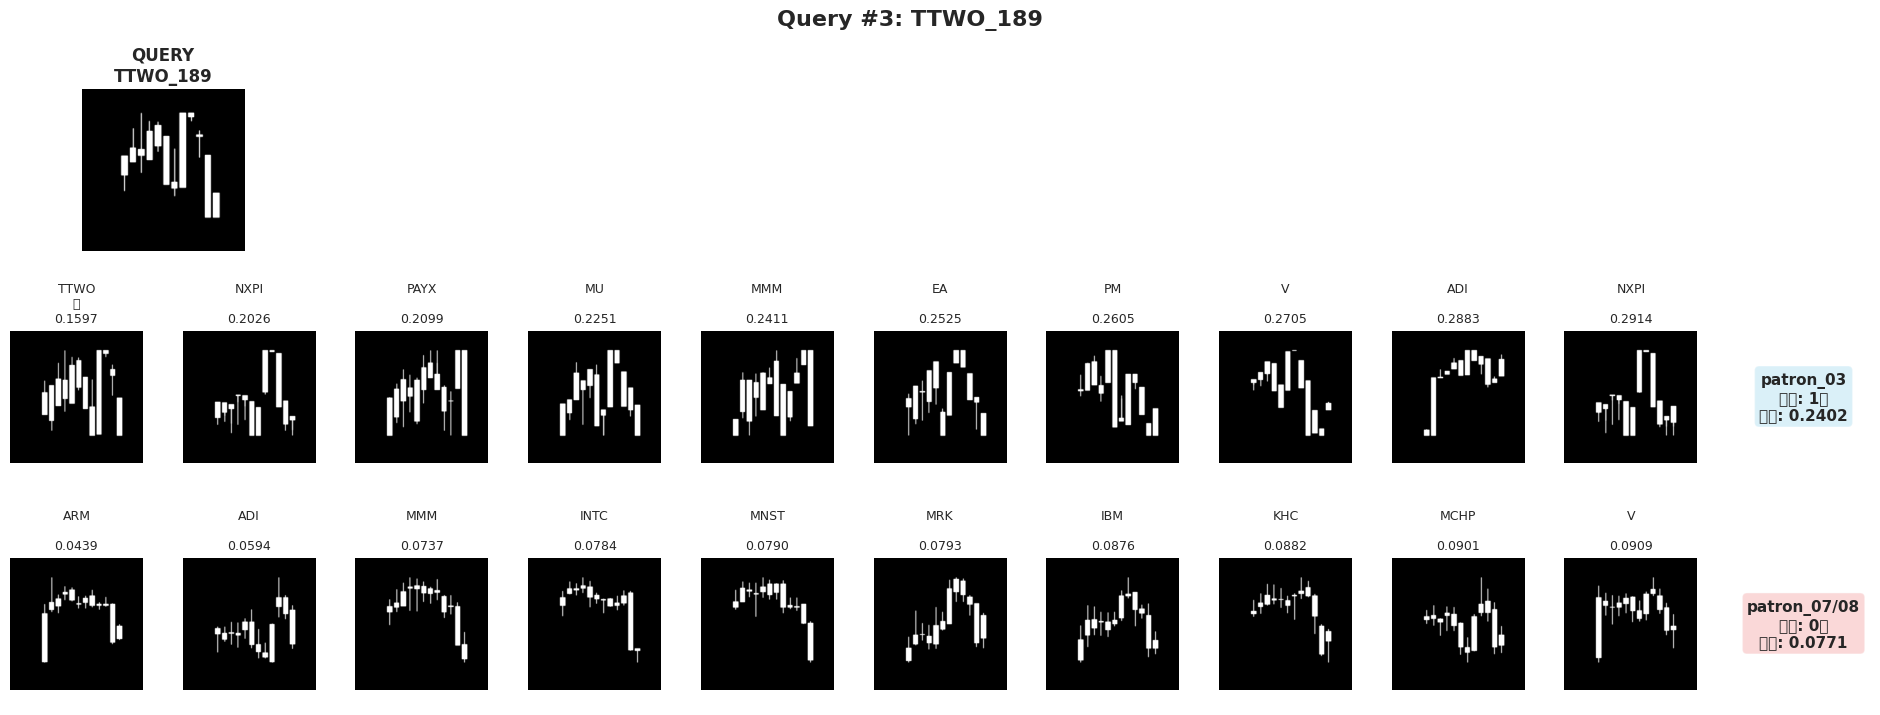

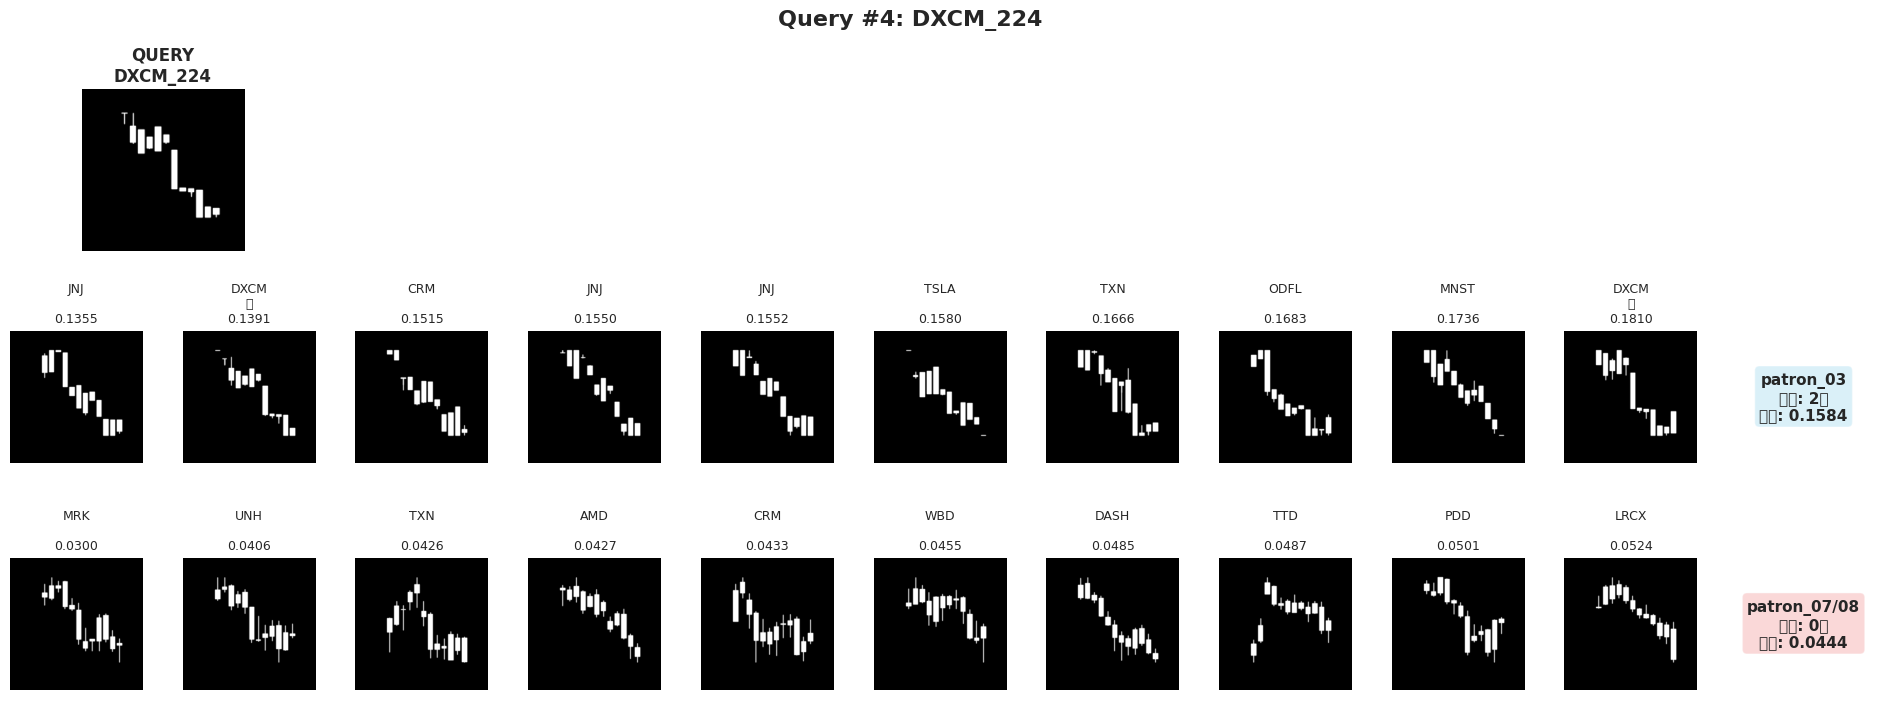

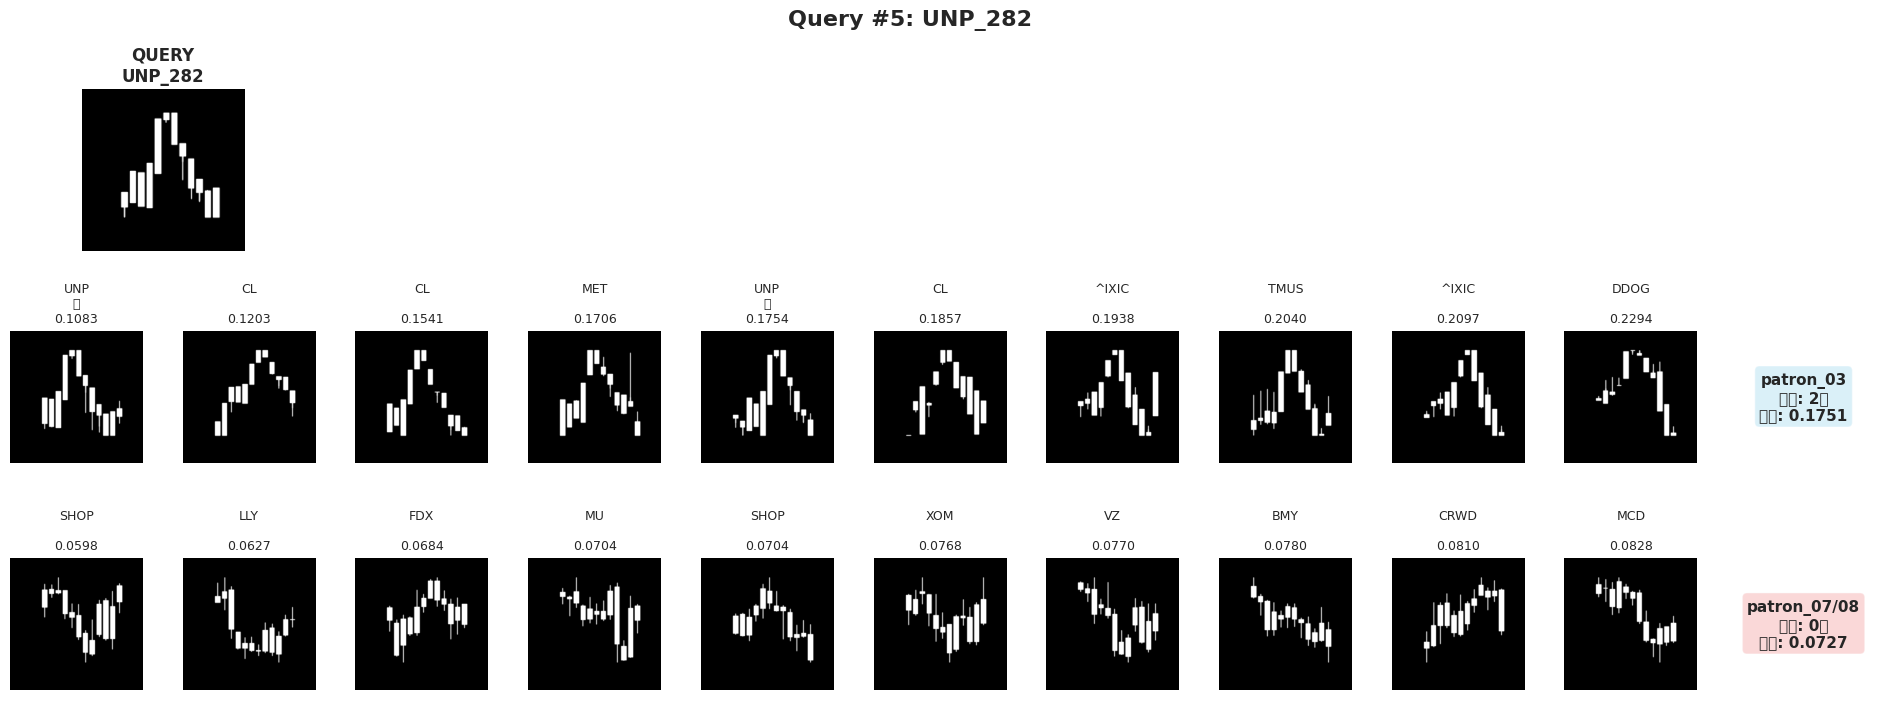

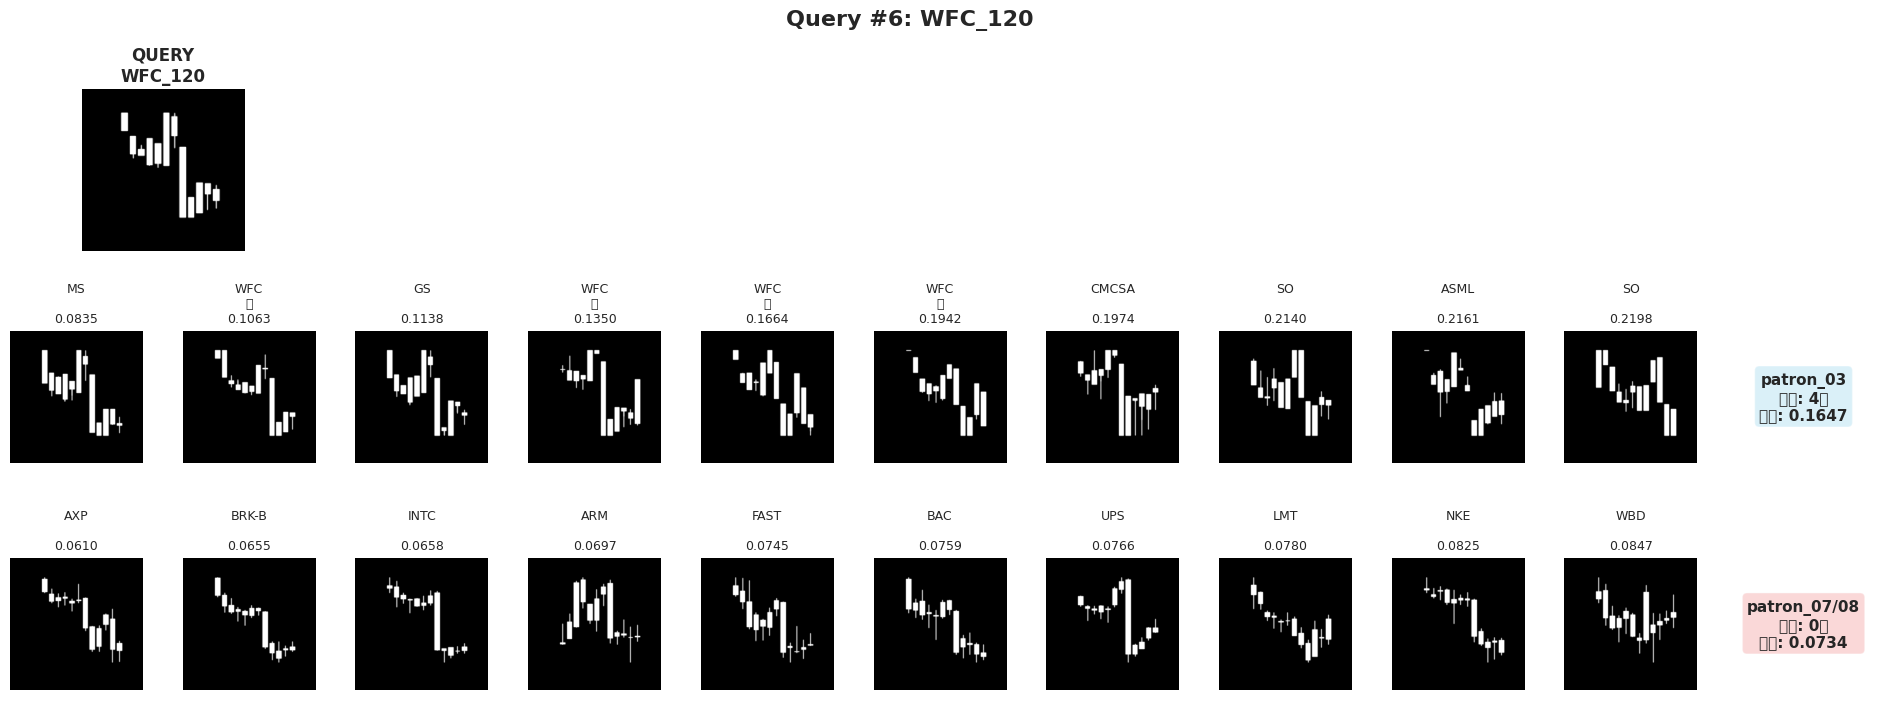

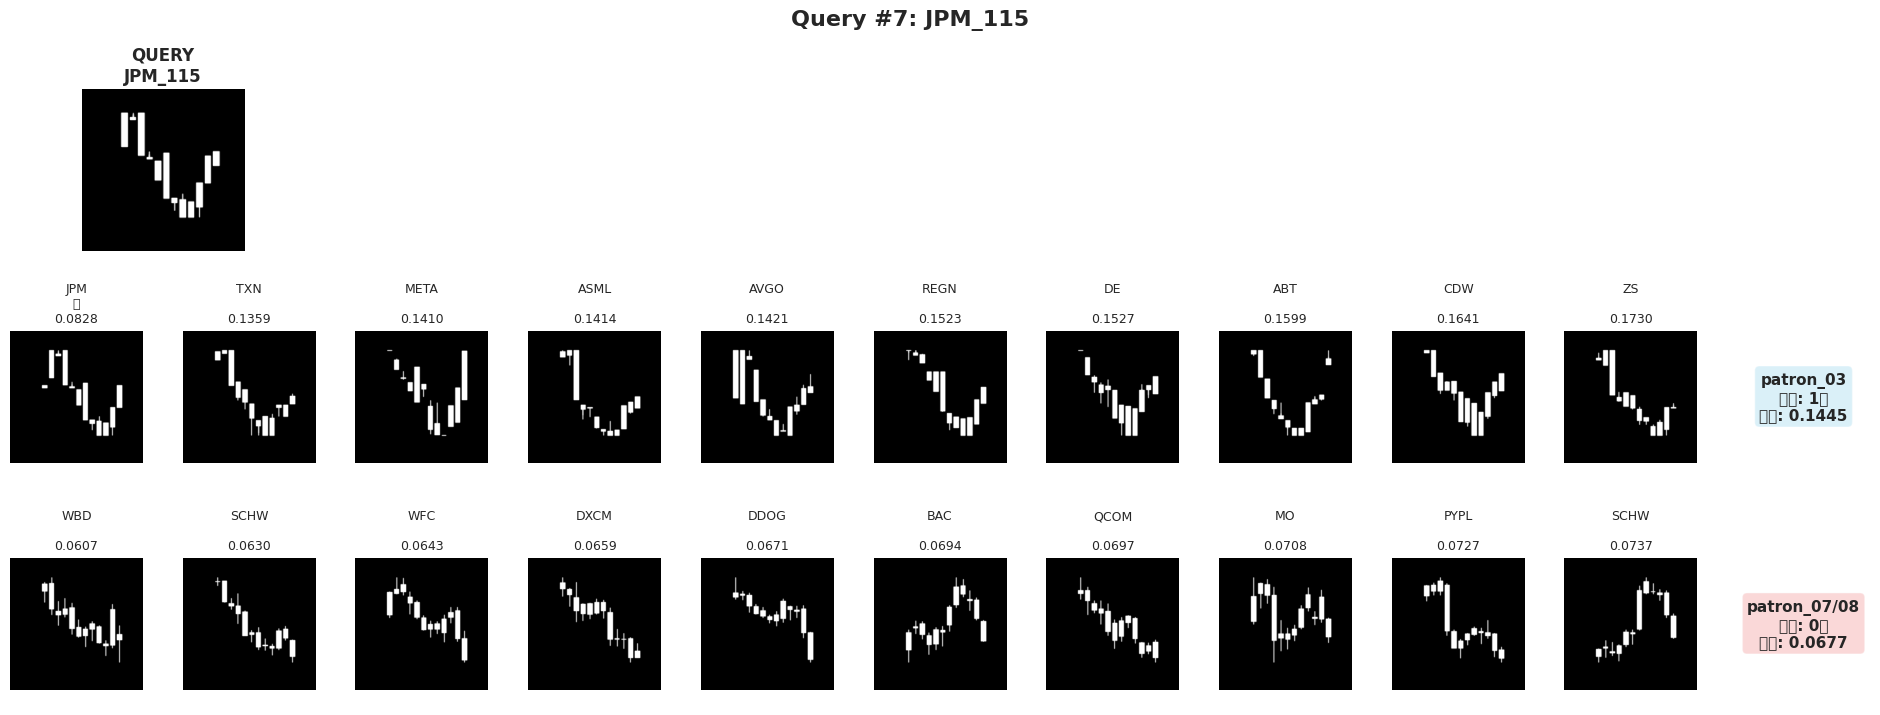

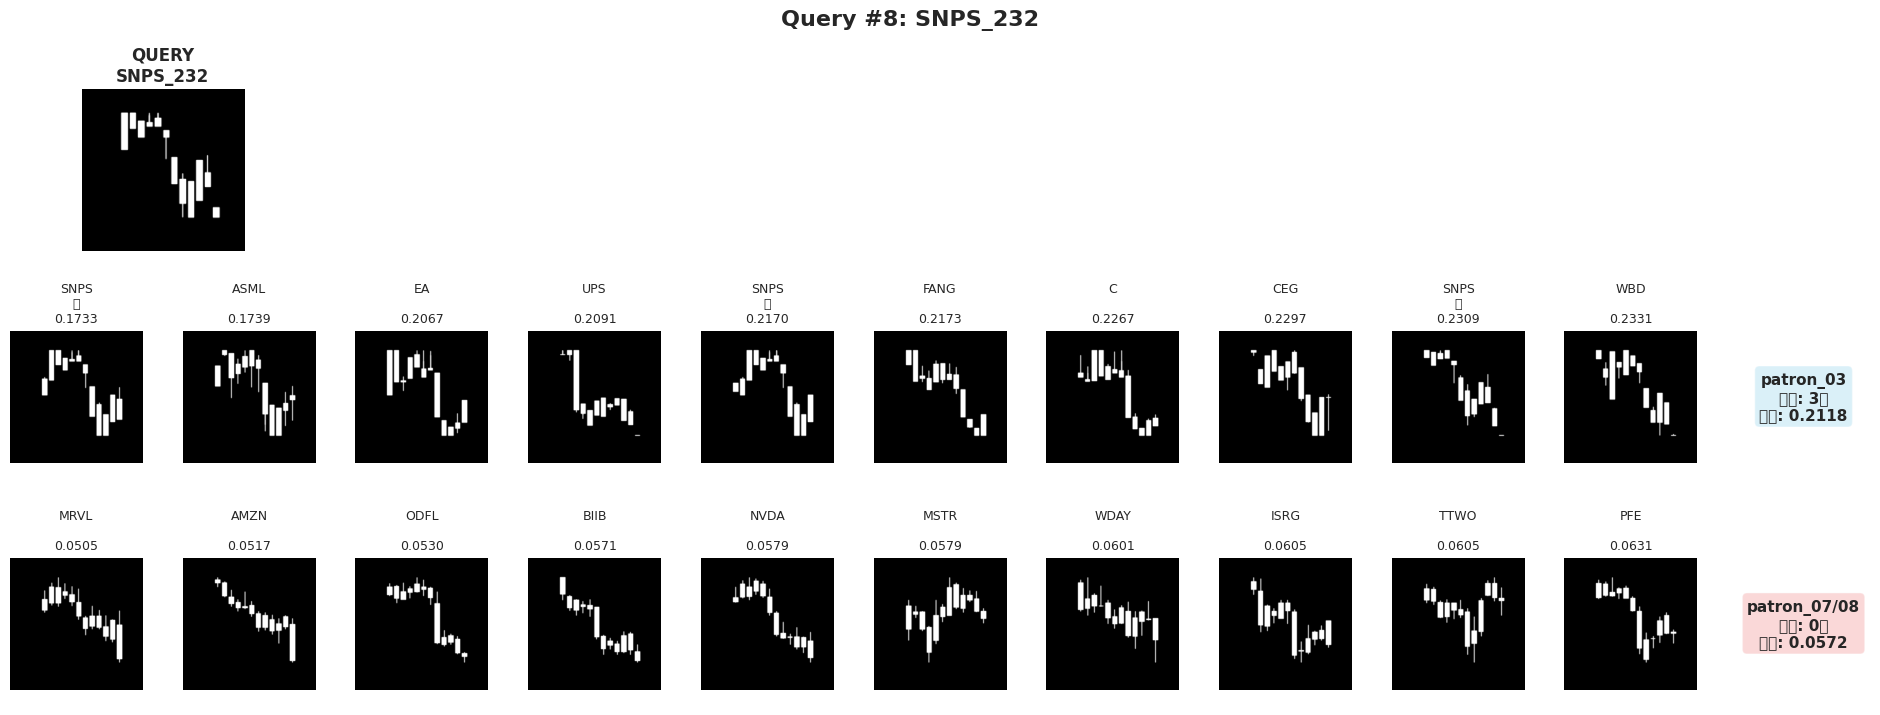

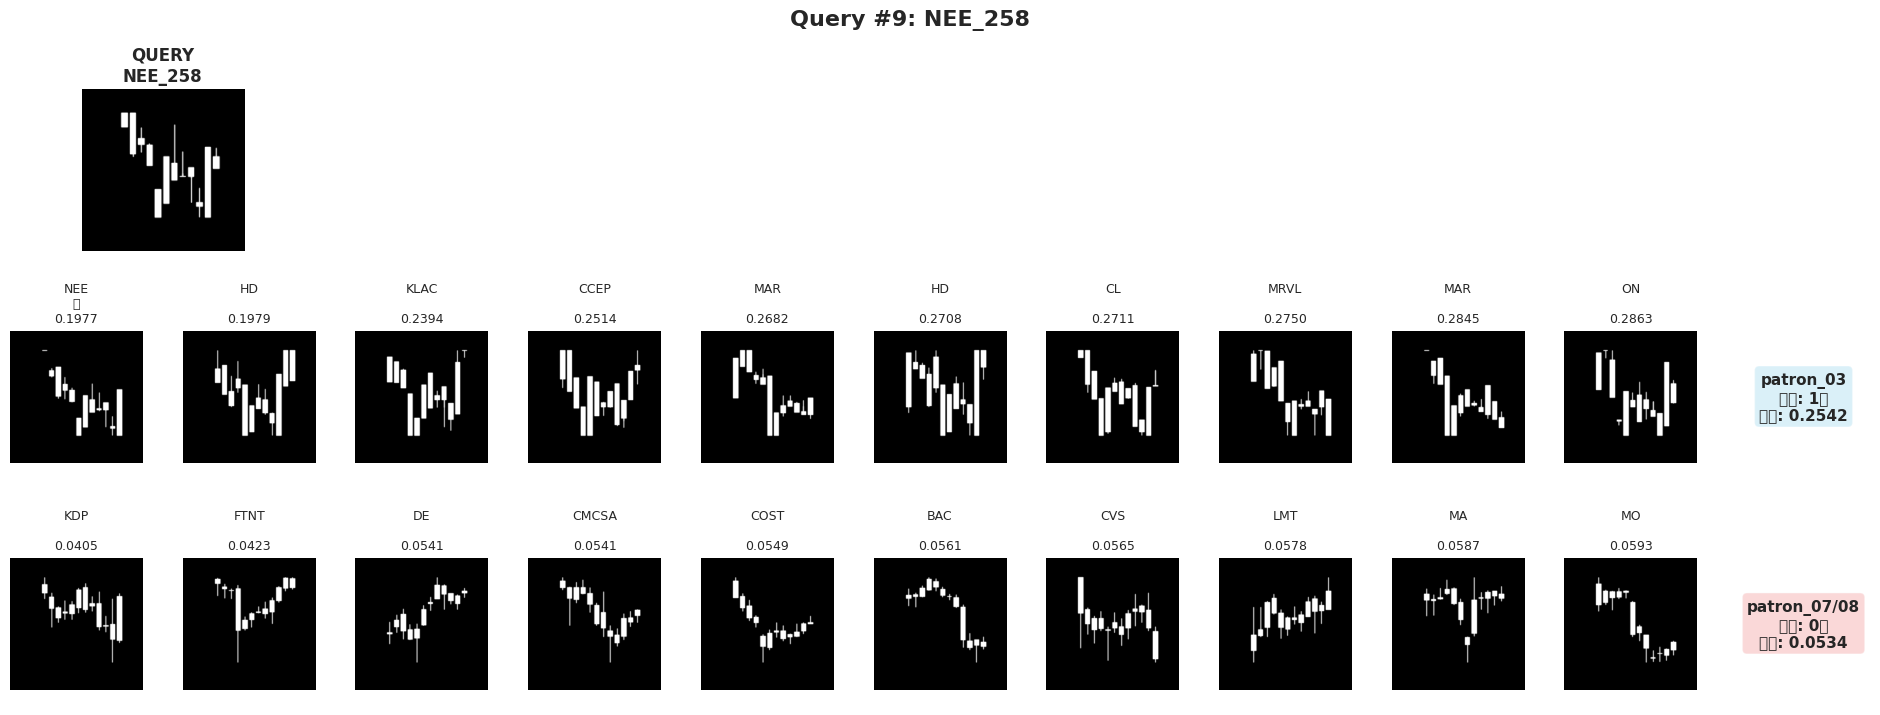

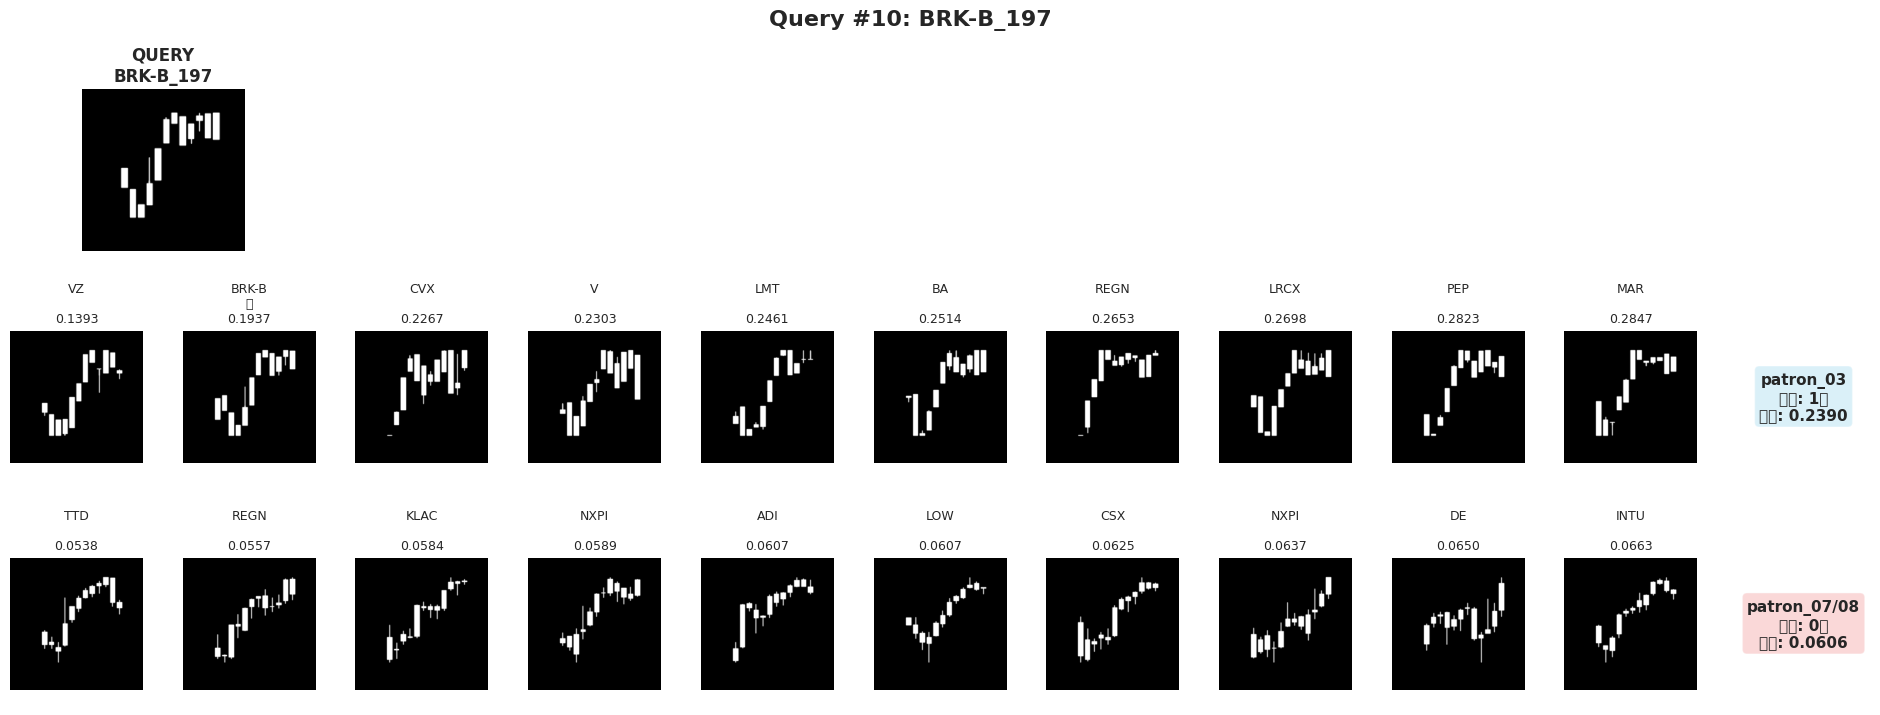

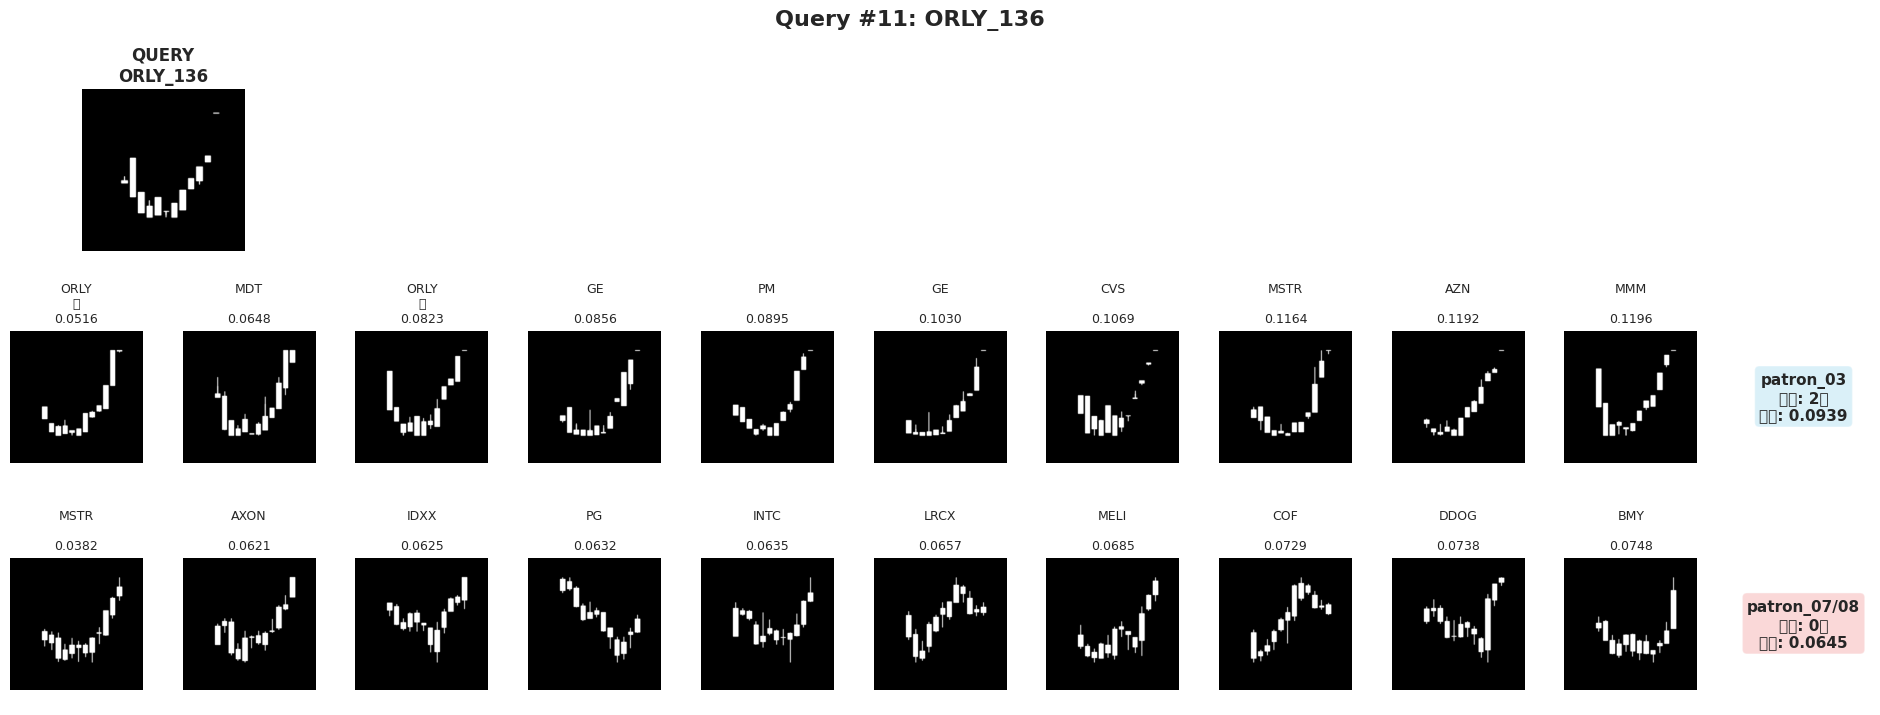

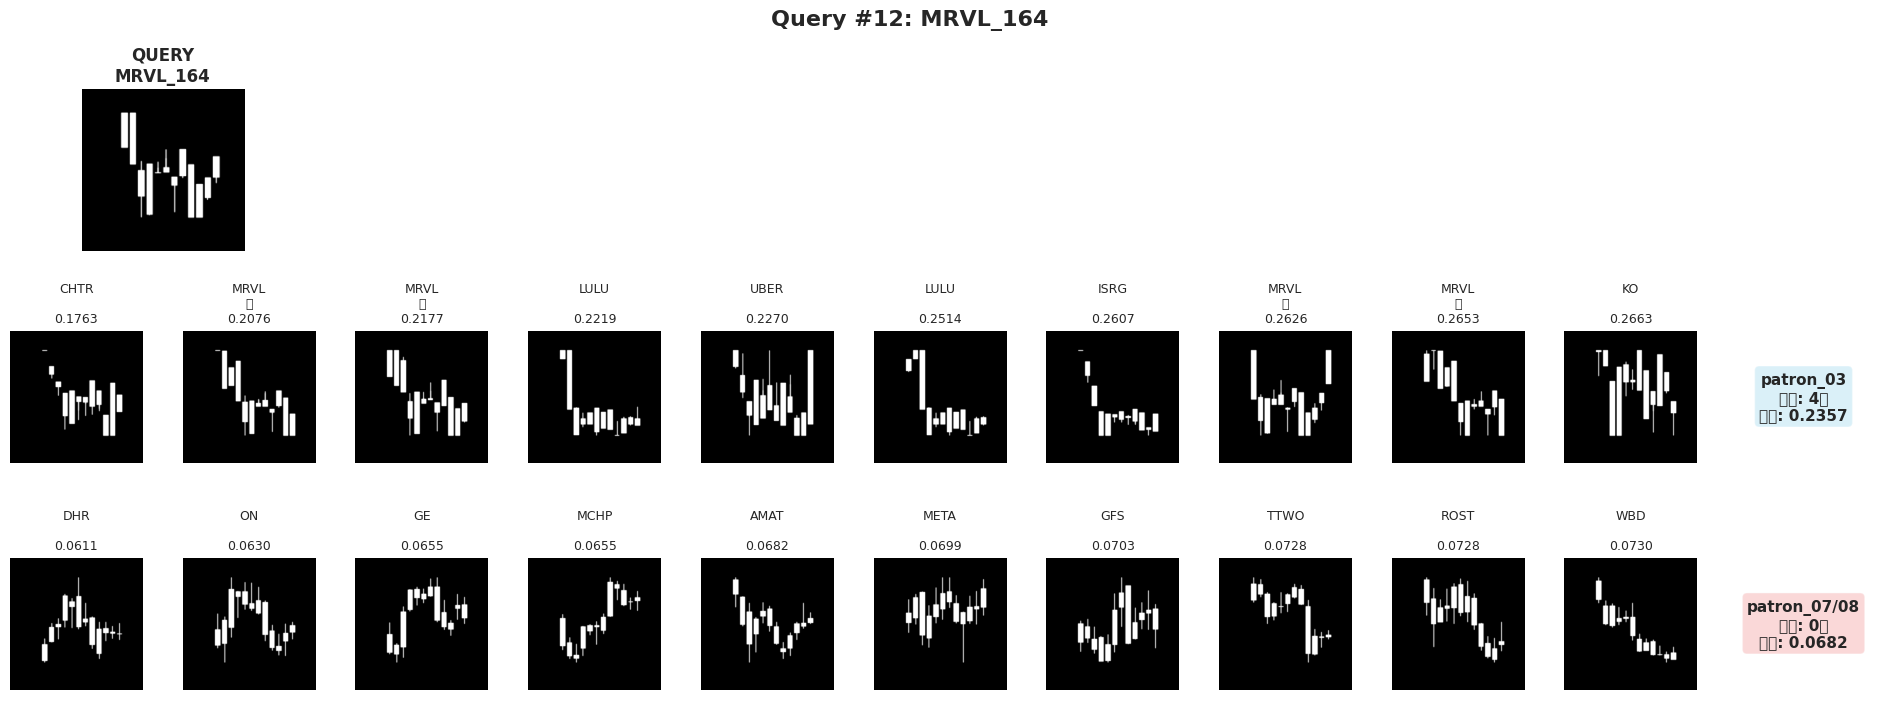

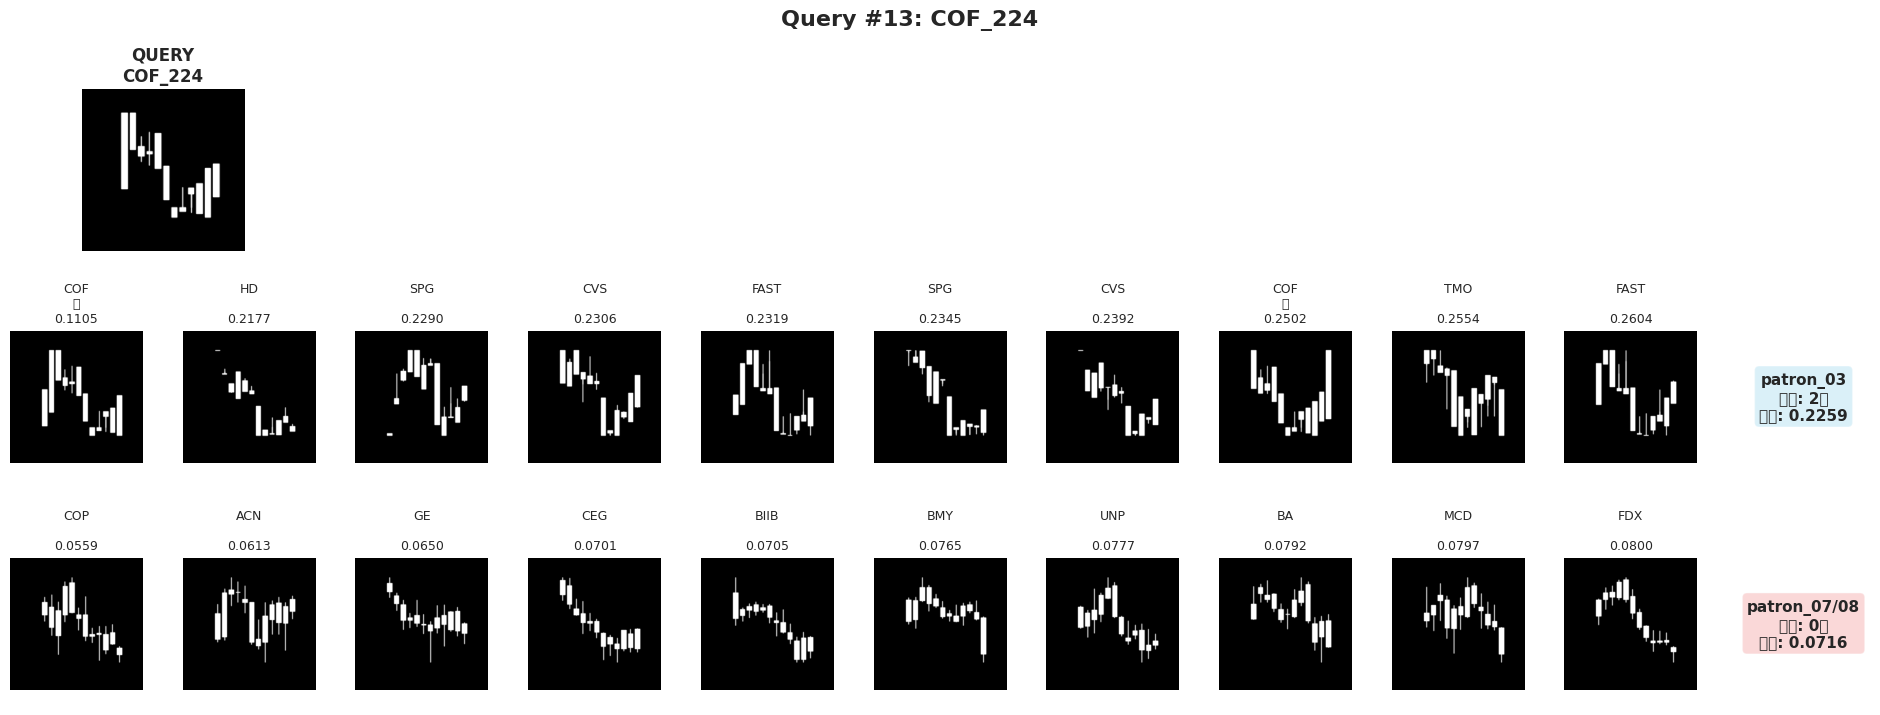

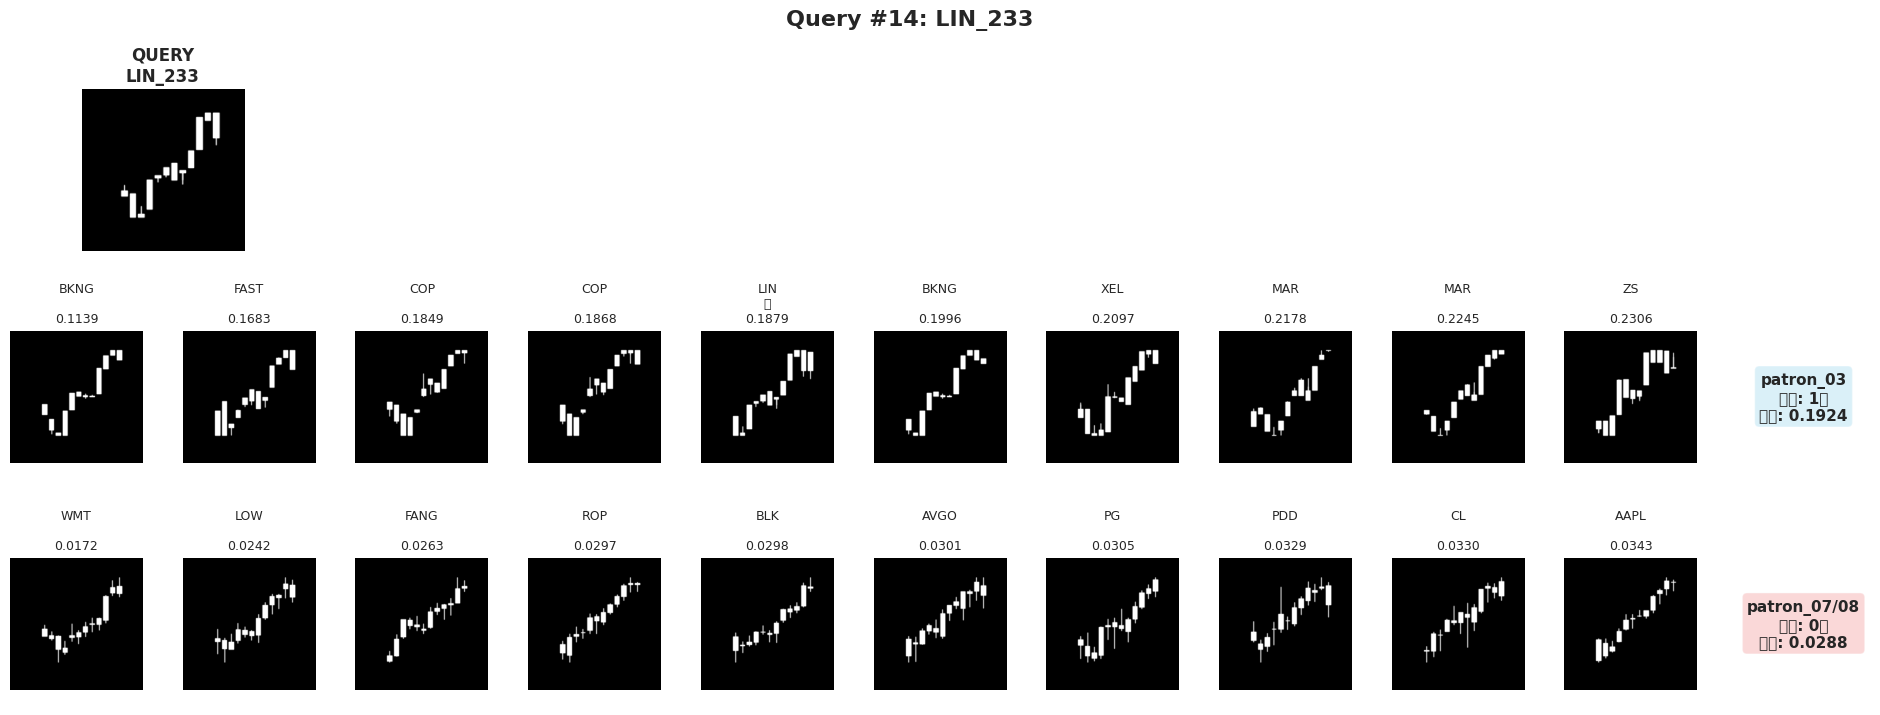

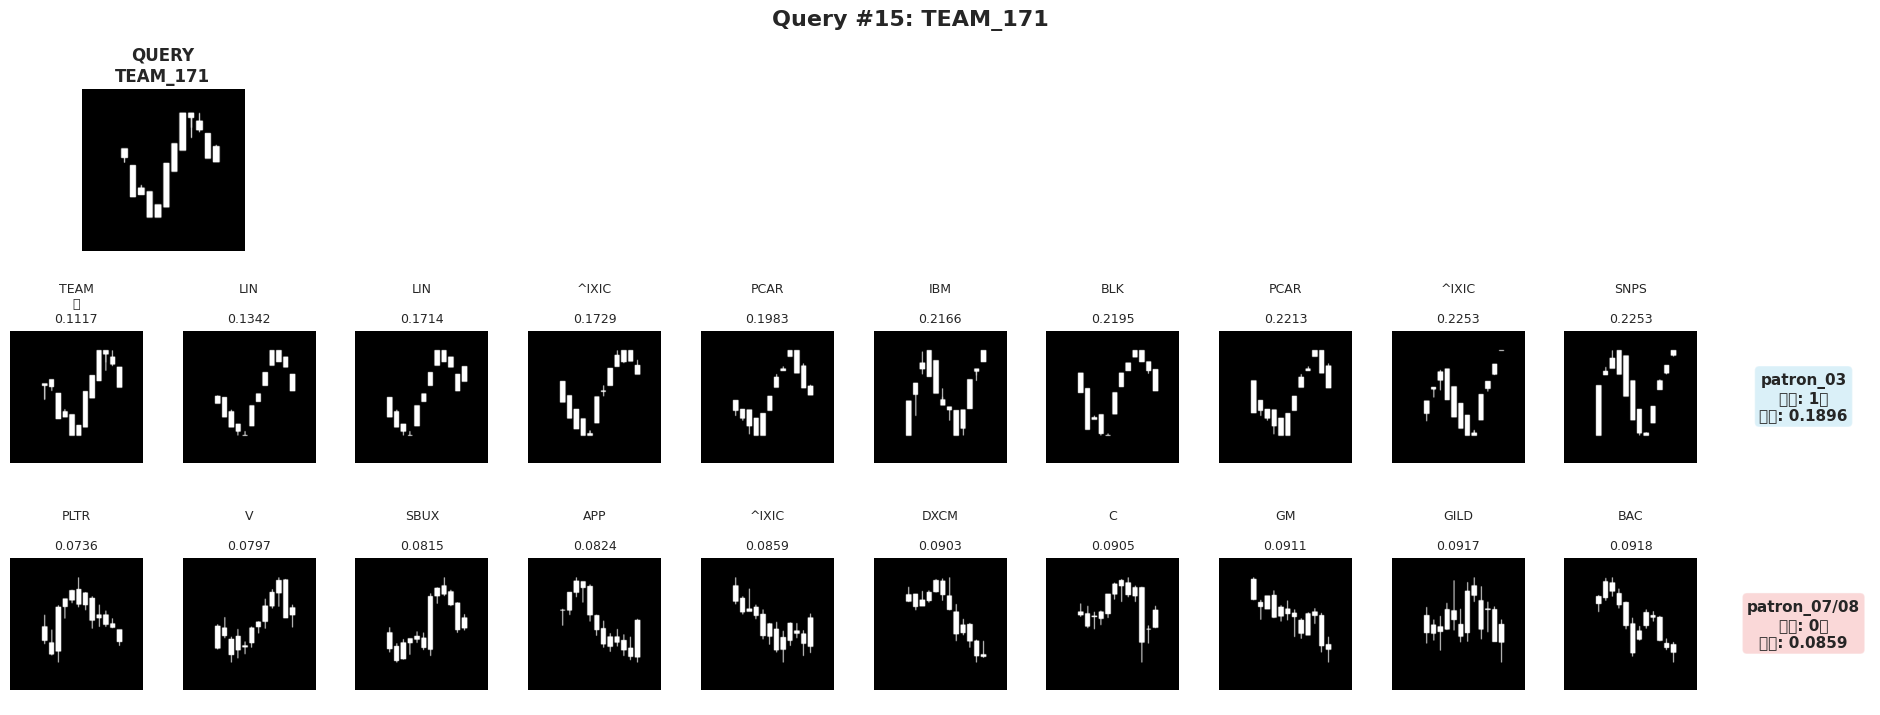

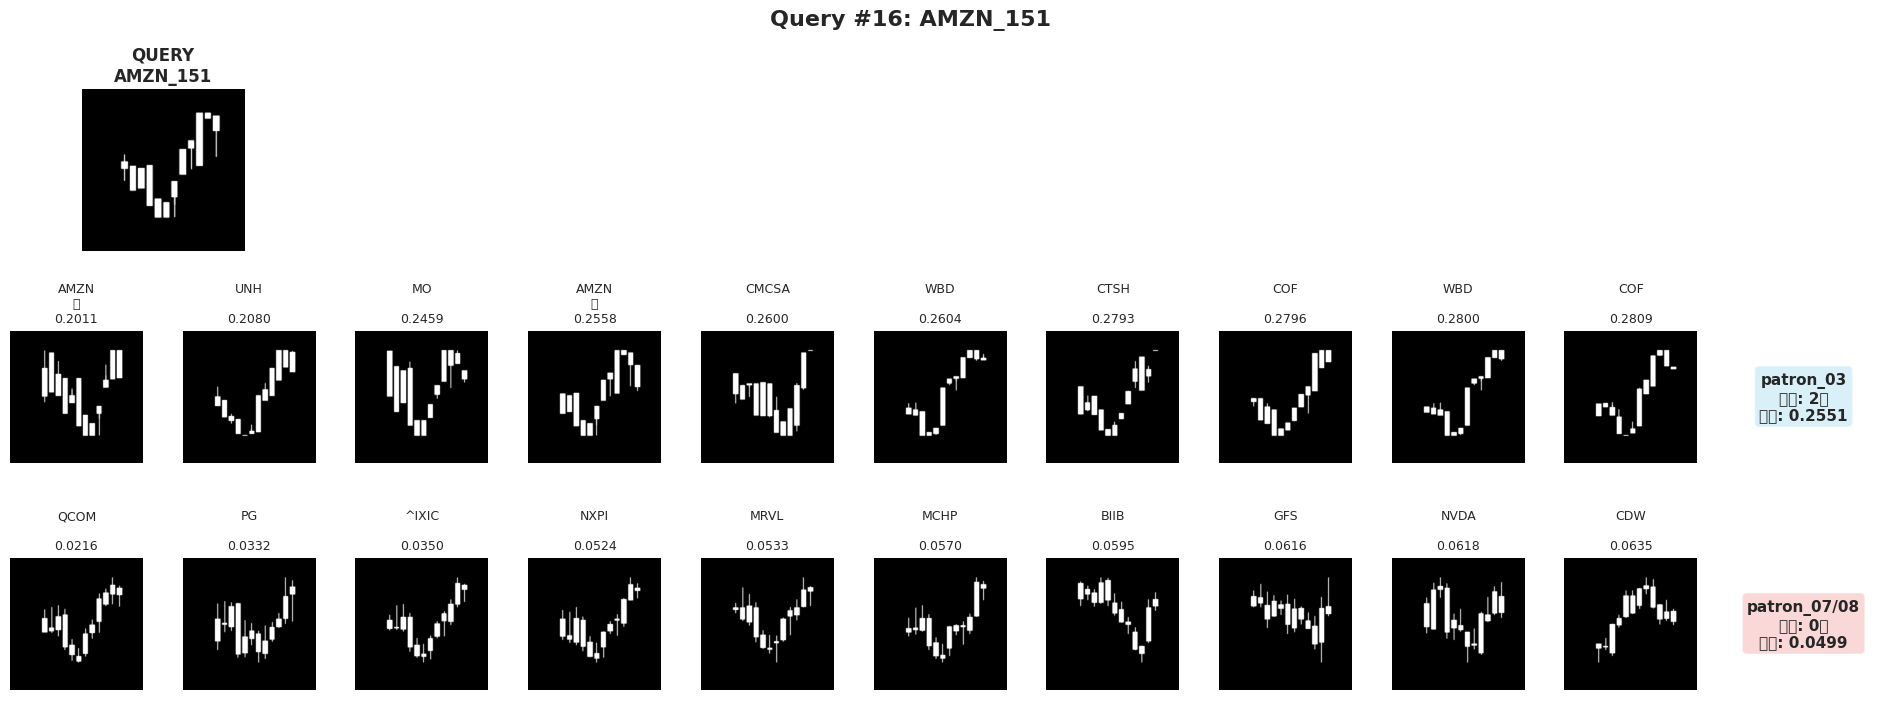

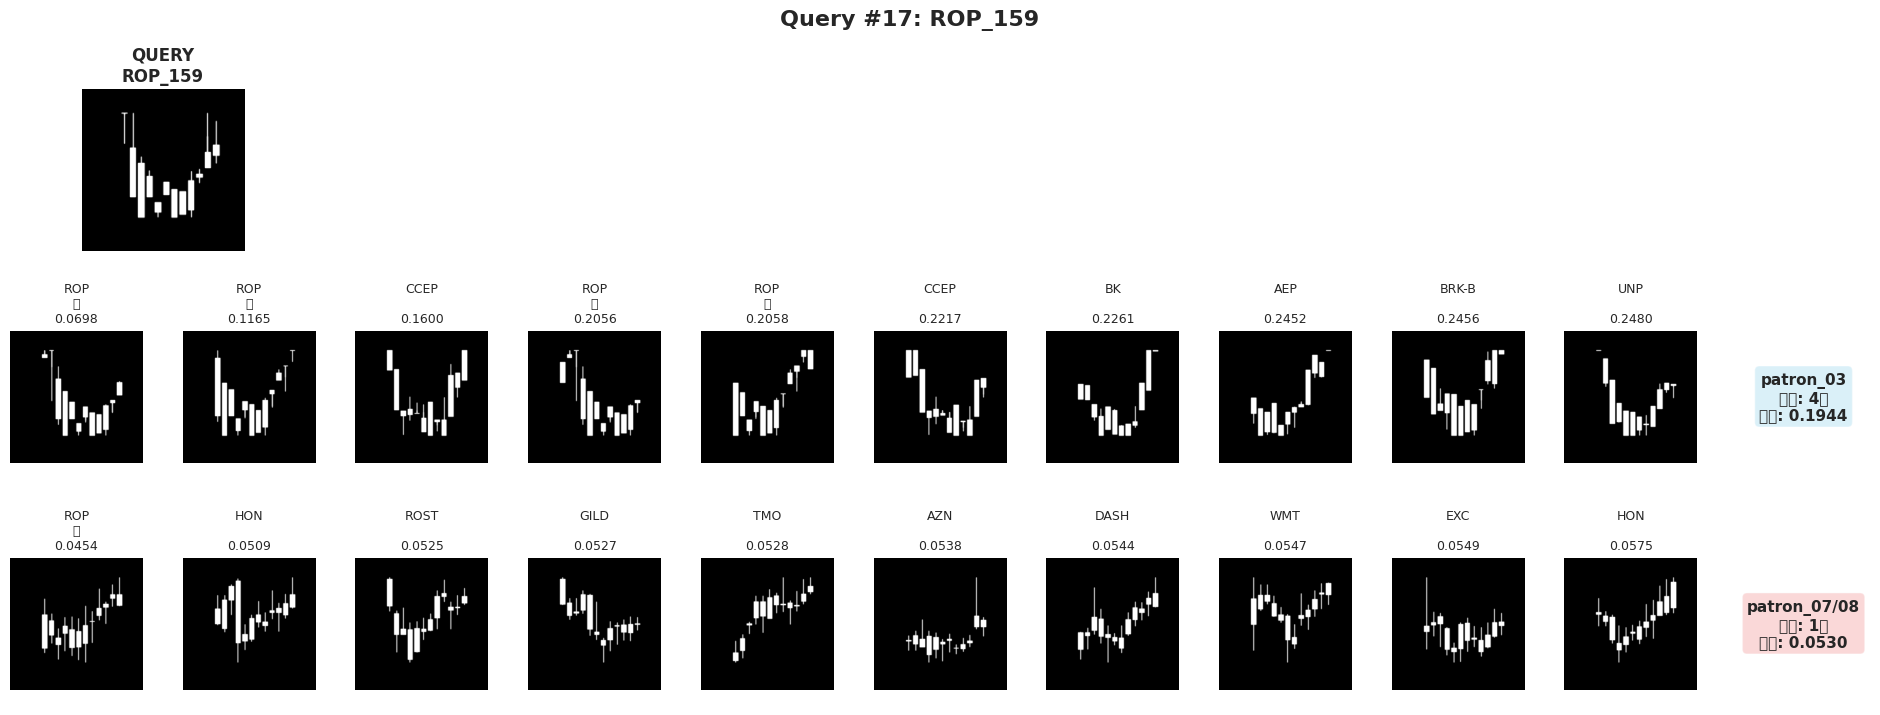

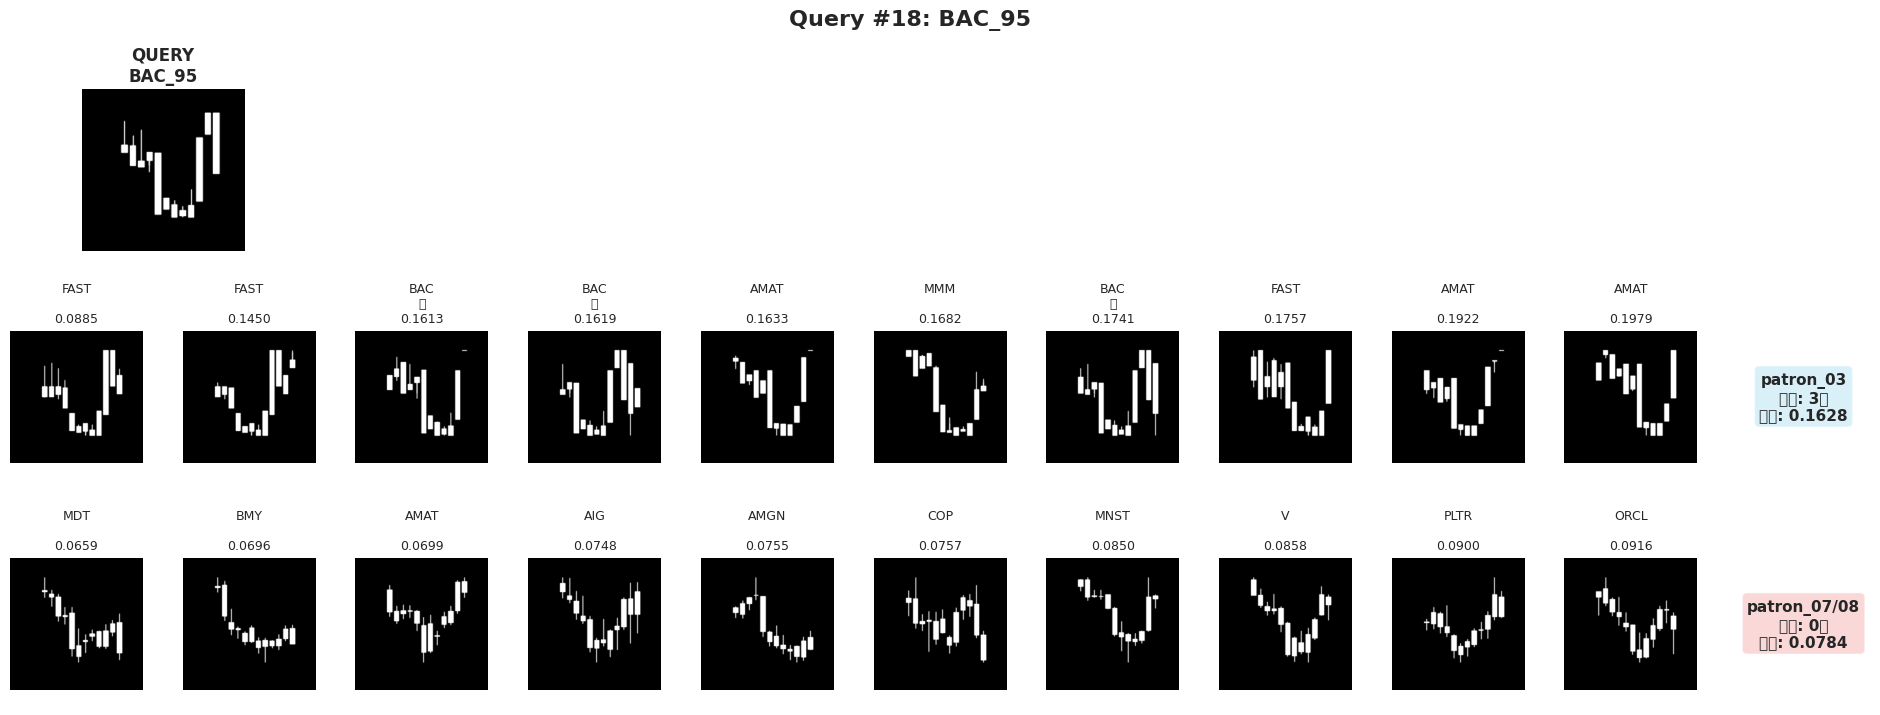

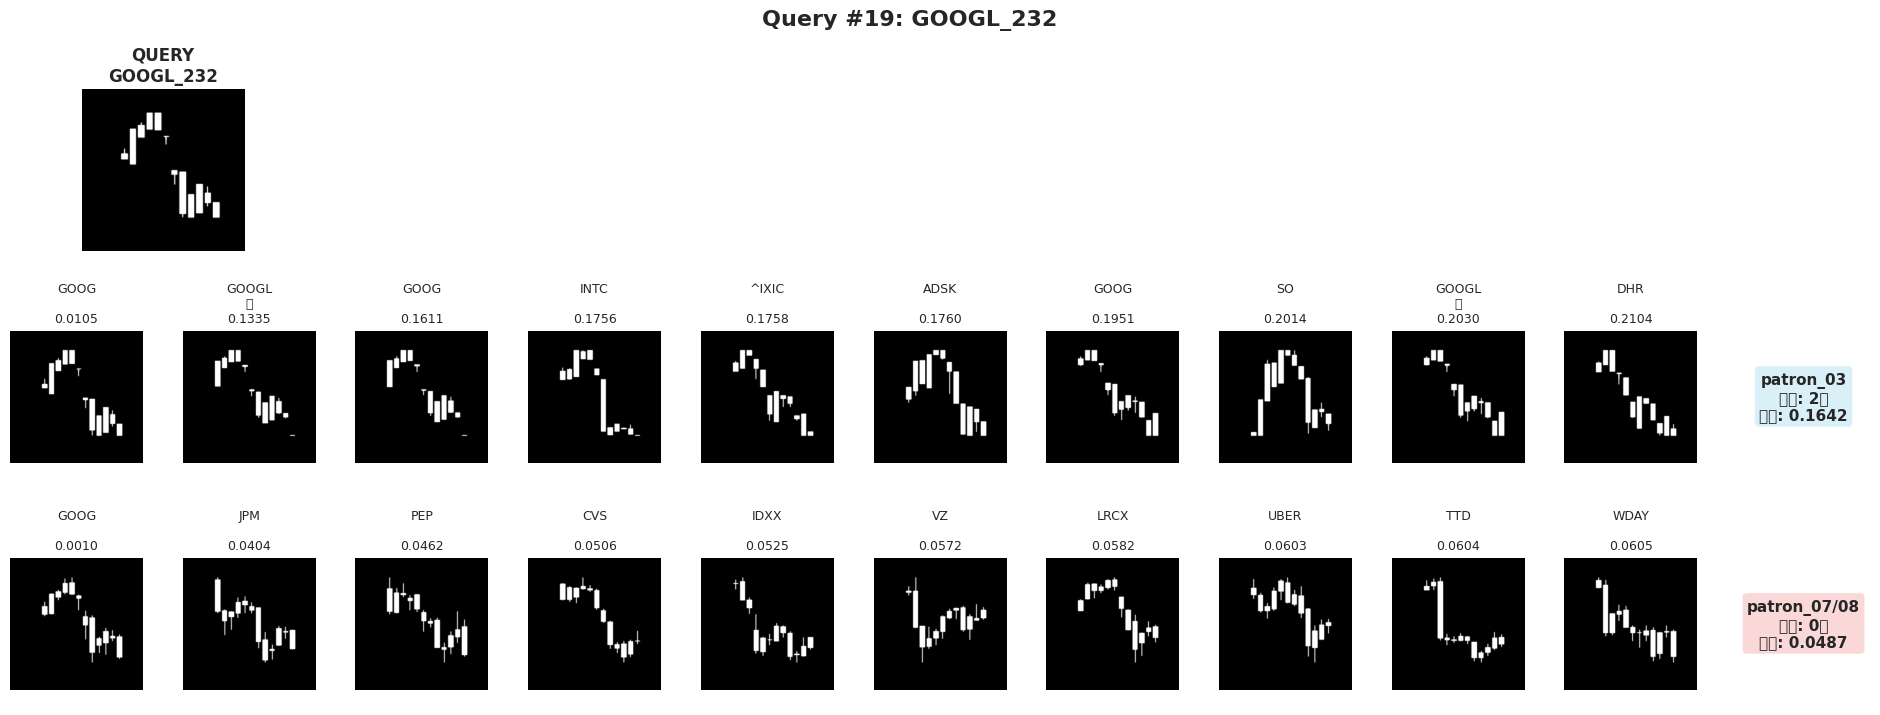

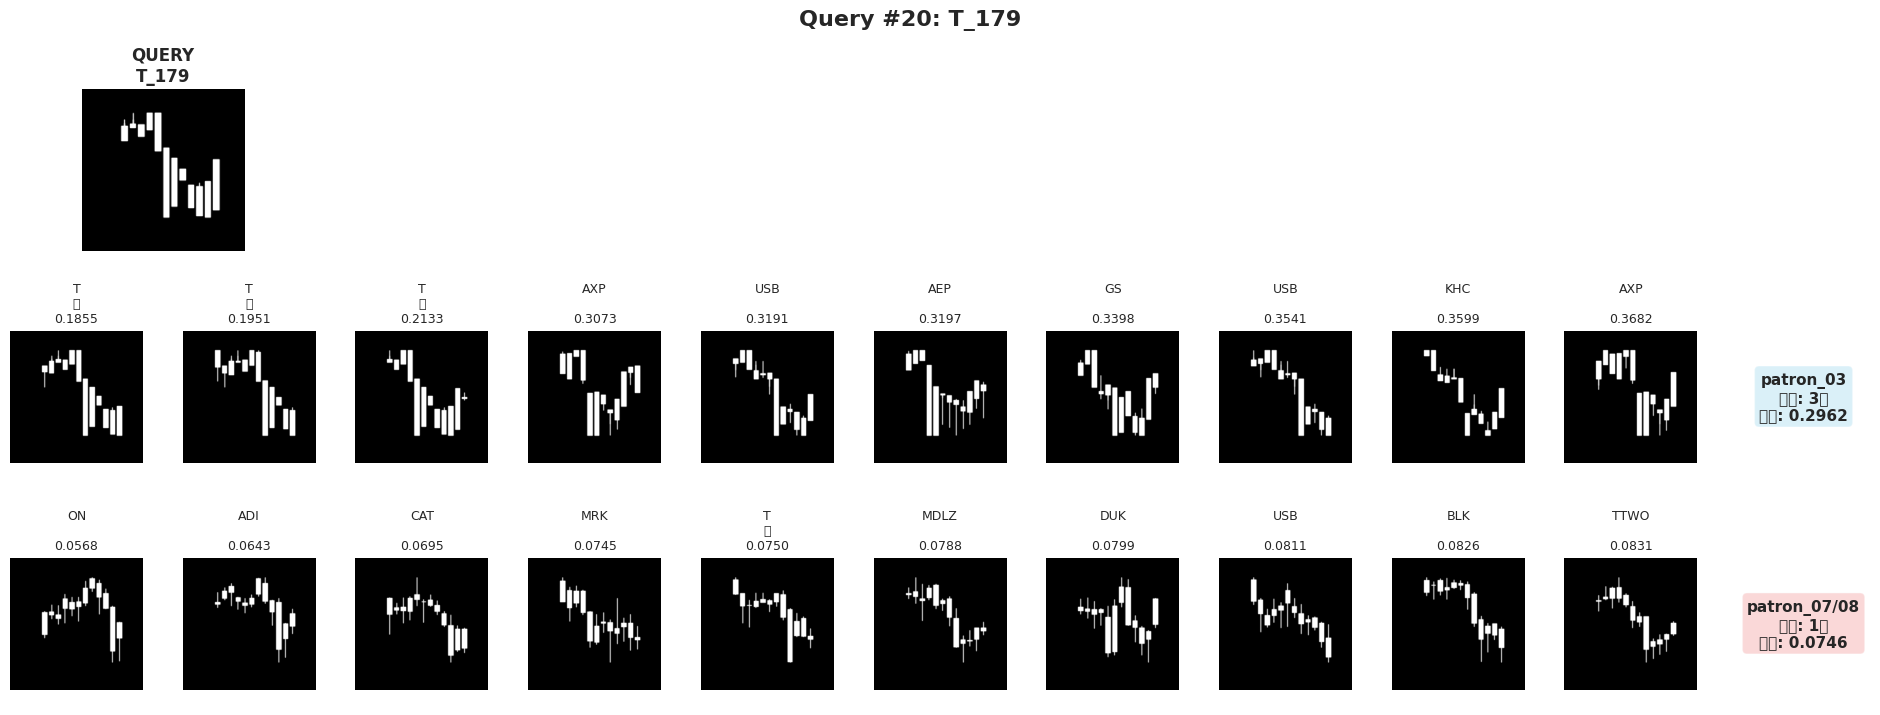


✅ 전체 시각화 완료!


In [17]:
# 20개 쿼리 전부 시각화!
print("="*80)
print("🖼️ 쿼리별 차트 이미지 비교 (20개)")
print("="*80)

for result in results:
    display_query_comparison(result, metadata_v1, metadata_v2, IMAGE_V1_DIR, IMAGE_V2_DIR)

print("\n✅ 전체 시각화 완료!")

## 14. 최종 결론

정량 지표를 집계하고 최종 모델 선택을 결론짓는다. 수치상 patron_07/08이 우세하지만, 위 시각적 비교에서 확인한 바와 같이 patron_03(실험 1)이 실제 사용 목적인 "시각적으로 유사한 차트 패턴 검색"에 더 적합하다. 실험 1을 최종 채택한다.

In [18]:
print("="*80)
print("🎯 최종 결론")
print("="*80)

print("\n[정량적 비교]")
print(f"1. 평균 중복 개수: patron_03({np.mean(duplicates_v1):.2f}개) vs patron_07/08({np.mean(duplicates_v2):.2f}개)")
print(f"   → patron_07/08이 {((np.mean(duplicates_v1) - np.mean(duplicates_v2)) / np.mean(duplicates_v1) * 100):.1f}% 개선")

print(f"\n2. Top-1 평균 거리: patron_03({np.mean(min_dist_v1):.4f}) vs patron_07/08({np.mean(min_dist_v2):.4f})")
if np.mean(min_dist_v2) < np.mean(min_dist_v1):
    print(f"   → patron_07/08이 더 가까운 패턴 찾음 ✅")
else:
    print(f"   → patron_03이 더 가까운 패턴 찾음")

print(f"\n3. Top-10 평균 거리: patron_03({np.mean(avg_dist_v1):.4f}) vs patron_07/08({np.mean(avg_dist_v2):.4f})")
if np.mean(avg_dist_v2) < np.mean(avg_dist_v1):
    print(f"   → patron_07/08이 전체적으로 더 유사한 패턴 검색 ✅")
else:
    print(f"   → patron_03이 전체적으로 더 유사한 패턴 검색")

print("\n[정성적 평가]")
print("위의 차트 이미지를 눈으로 확인하여:")
print("- 시각적으로 유사한 패턴을 찾는가?")
print("- 중복이 많아도 진짜 유사해서 중복인가?")
print("- 다양한 종목에서 유사 패턴을 찾는가?")

print("\n[종합 평가]")
if np.mean(duplicates_v2) < np.mean(duplicates_v1) and np.mean(avg_dist_v2) < np.mean(avg_dist_v1):
    print("✅ patron_07/08이 patron_03보다 우수함!")
    print("   - 중복 적음 (다양한 종목 검색)")
    print("   - 거리 가까움 (더 유사한 패턴)")
    print("   - Log 정규화 + 새로운 Anchor-Positive 전략이 효과적!")
elif np.mean(duplicates_v2) < np.mean(duplicates_v1):
    print("⚖️ patron_07/08이 중복은 적지만 거리는 비슷함")
    print("   - 다양성은 증가했으나 유사도는 유지")
else:
    print("⚠️ patron_03이 patron_07/08보다 나을 수 있음")
    print("   - 시각적 평가 필요!")

print("\n💡 참고:")
print("- Loss 값 차이(26배)는 정규화 방식 차이 때문")
print("- 중복이 많다 = 나쁘다가 아님 (진짜 유사할 수 있음)")
print("- 최종 판단은 시각적 평가로!")
print("="*80)

🎯 최종 결론

[정량적 비교]
1. 평균 중복 개수: patron_03(2.20개) vs patron_07/08(0.15개)
   → patron_07/08이 93.2% 개선

2. Top-1 평균 거리: patron_03(0.1219) vs patron_07/08(0.0463)
   → patron_07/08이 더 가까운 패턴 찾음 ✅

3. Top-10 평균 거리: patron_03(0.1964) vs patron_07/08(0.0614)
   → patron_07/08이 전체적으로 더 유사한 패턴 검색 ✅

[정성적 평가]
위의 차트 이미지를 눈으로 확인하여:
- 시각적으로 유사한 패턴을 찾는가?
- 중복이 많아도 진짜 유사해서 중복인가?
- 다양한 종목에서 유사 패턴을 찾는가?

[종합 평가]
✅ patron_07/08이 patron_03보다 우수함!
   - 중복 적음 (다양한 종목 검색)
   - 거리 가까움 (더 유사한 패턴)
   - Log 정규화 + 새로운 Anchor-Positive 전략이 효과적!

💡 참고:
- Loss 값 차이(26배)는 정규화 방식 차이 때문
- 중복이 많다 = 나쁘다가 아님 (진짜 유사할 수 있음)
- 최종 판단은 시각적 평가로!


---

## 최종 선택: 실험 1 (patron_03, MinMaxScaler)

정량 지표에서는 실험 3(patron_07/08)이 중복 종목 수 93.2% 감소, L2 거리 68% 단축으로 압도적으로 우수하다. 그러나 실제 차트 이미지 비교에서 실험 3의 결과는 쿼리 패턴과 시각적으로 다른 형태의 차트가 다수 포함됐다.

이 차이는 Log Base 정규화의 특성에서 비롯된다. Log 정규화는 가격 비율을 보존하지만 절대적인 차트 형태(캔들 크기, 고저 비율)를 왜곡해, 눈으로 보기에 다른 패턴도 임베딩 공간에서 가깝게 매핑된다.

**최종 채택 모델: patron_03 (실험 1, MinMaxScaler)**

다음 단계:
1. patron_03 모델로 전체 패턴 임베딩 재생성 (08번)
2. FastAPI 서빙용 embeddings.npy + faiss_index.bin 생성 (09번)